# MeteoScreening `SWC_FF1_0.2_1` (2020-2025) from database (influxdb)


***
**Site**: CH-LAE &nbsp;&nbsp;|&nbsp;&nbsp; **Variable**: `SWC_FF1_0.2_1` (20 cm depth) &nbsp;&nbsp;|&nbsp;&nbsp; **Period**: 2020-2025
**Cross-check**: the other depths of the same soil profile (`0.05`, `0.1`, `0.3`, `0.5` m) and the screened precipitation product — see *Cross-check* below
**Derived from**: the `SWC_FF1_0.05_1` pattern notebook (itself a copy of the diive template `DatabaseInfluxStepwiseMeteoScreening.ipynb`, version `9`, 15 Jul 2026)
**Author**: Lukas Hörtnagl (holukas@ethz.ch)

## ℹ️ About this notebook
Download raw soil water content from the InfluxDB database, quality-screen and correct it on the **high-resolution** data, resample to 30MIN, and upload the result back to the database. Screening uses `StepwiseMeteoScreeningDb` from [diive](https://github.com/holukas/diive) (`diive/preprocessing/qaqc/meteoscreening.py`); download and upload use diive's in-house InfluxDB engine (`InfluxIO`, in `diive/core/io/db/influx`).

**Flow:** download (`InfluxIO`) → cross-check against the rest of the soil profile → screen on high-res data (`diive`) → resample to 30MIN → validate against the profile → upload.

**Outlier detection is stepwise:** run a test, inspect its preview plot, then commit it with `mscr.addflag()`. Re-run with different parameters as often as you like before committing. Run only the tests a variable actually needs. At the end all committed flags are aggregated into one overall quality flag `QCF`.

**This is the 20 cm sensor of the FF1 profile.** It is screened by a copy of the `SWC_FF1_0.05_1` pattern notebook, with `DEPTH` set to `0.2` and every removal window re-derived from this sensor's own evidence. The short version of that evidence: **this record is clean.** Absolute limits removes the failed sensor reads, the gaps are already missing, and there is *no* decoupled-probe episode of the kind that forced a manual removal at 5 cm — so `REMOVE_DATES` is **empty** here. The one fieldbook incident that names this location (27 Jun 2025, `TS_FF1_02_1` "does not work regularly since 27.02") concerns the co-located soil *temperature* sensor, not this probe: across 27 Feb–6 Jul 2025 the soil-water record is complete (≈ 1440 records/day), in range, and tracking the profile, so the incident leaves no trace to remove. The *No spike test* and closing sections lay out the numbers.

> **Database access** needs the `influxdb-client` package, which this project pulls in via the **`diive[db]` extra** (declared in `pyproject.toml`). Note that diive *also* ships a `db` dependency group, but dependency groups are local to the project that declares them — `uv sync --group db` only works inside the diive repo, not from here. From this repo the extra is the only route.

## ⏱️ Timestamp convention (important)
The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`** (the stamp marks the *end* of the averaging interval). Getting the timestamp right is the one thing that must not go wrong, because the day/night split during screening — and the value written back to the DB — both depend on it.

The single knob is `TIMEZONE_OFFSET_TO_UTC_HOURS` (set in *User settings*). It is applied **identically** on download and on upload. Here is the full round-trip, all handled for you:

| Stage | Timezone | Convention | Done by |
|---|---|---|---|
| Database | UTC | `TIMESTAMP_END` | InfluxDB |
| After `dbc.download(..., timezone_offset_to_utc_hours=N)` | local (UTC+N) | `TIMESTAMP_END` | InfluxIO |
| During screening | local | `TIMESTAMP_MIDDLE` (converted internally) | `StepwiseMeteoScreeningDb` |
| After `mscr.resample()` | local | back to `TIMESTAMP_END` | diive |
| After `dbc.upload_singlevar(..., timezone_offset_to_utc_hours=N)` | UTC | `TIMESTAMP_END` | InfluxIO |

So screening runs on correct local middle-of-period timestamps, and the resampled value lands on the correct UTC end-of-period stamp in the DB. **`TIMEZONE_OFFSET_TO_UTC_HOURS` must match the timezone the raw data was logged in** (e.g. `1` for CET winter time) and must be the same value everywhere. This notebook prints the timestamps right after download and right after the verification download so you can confirm they look correct.

Everything in the *Cross-check* section works on `TIMESTAMP_END` as downloaded. The precipitation product read there is stored on `TIMESTAMP_MID` and is shifted to `TIMESTAMP_END` before use.

## ✏️ User settings (please adjust)

Adjust these before running. What each setting means:

**Site**
- `SITE`, `SITE_LAT`, `SITE_LON`: site ID and coordinates. The coordinates set the day/night split used during screening (not used for soil moisture — see *Outlier detection*).

**Variable to screen**
- `PROFILE`, `DEPTH`, `REPL`: the sensor's position tags. `FIELD` is assembled from them and is the InfluxDB `_field`. **This is the only place to change when screening another depth.**
- `MEASUREMENT`: exactly **one** measurement grouping the variables — `SWC` for soil water content.
- `COMPANION_DEPTHS`: the other depths of the same profile, used as the cross-check reference. They are *not* screened here.

**Time range to screen**
- `START`: first timestamp to screen — **is** included.
- `STOP`: upper bound — **is not** included.

**Data settings**
- `TIMEZONE_OFFSET_TO_UTC_HOURS`: the critical timestamp knob — see the *Timestamp convention* section above. Must match how the raw data was logged (e.g. `1` for CET winter time).
- `DATA_VERSION`: the source data version in the database (`raw`).
- `DIRCONF`: local folder holding the database connection config.

**Resampling**
- `RESAMPLING_FREQ`: the screened high-res data is resampled to this frequency.
- `RESAMPLING_AGG`: aggregation used when resampling. Soil water content is a **state**, so `'mean'` — never `'sum'`.

**Cross-check**
- `PREC_PRODUCT` / `PREC_COL`: the screened precipitation product, used to test whether the sensor still *responds* to rain. Produced by [`30_PRODUCTS/08_METEO_PREC_2004-2025.ipynb`](../../30_PRODUCTS/08_METEO_PREC_2004-2025.ipynb).
- `PROFILE_PRODUCT`: the raw FF1 profile file holding all five depths, read here as the companion reference so the other depths are not downloaded again in every depth's notebook. Produced by [`SWC_FF1_PROFILE_2020-2025.ipynb`](SWC_FF1_PROFILE_2020-2025.ipynb). The screened variable itself still comes from the database download — it needs the database tags this values-only file does not carry.
- `FIELDBOOK`: the GIN fieldbook export, read directly here so that every candidate period is adjudicated against the site record in the notebook rather than by hand.

**Parameter help**
- `SHOW_PARAM_HELP`: set `True` to print the full docstring (all parameters) of each screening method right before it runs. Leave `False` for a clean, concise notebook.

In [1]:
# --- Site ---
SITE = 'ch-lae'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

# --- Variable to screen ---
# Verified 21 Jul 2026 against measurement SWC of bucket ch-lae_raw: the FF1 profile
# holds five depths (0.05, 0.1, 0.2, 0.3, 0.5), all TEROS 12, all starting
# 2020-04-10. (The older M5 profile, SWC_M5_*, ends the same day and is a
# different, now-trashed sensor set - see the closing note. The FF3 profile
# starts only in 2026 and is out of scope here.)
PROFILE = 'FF1'  # horizontal position (soil profile)
DEPTH = '0.2'  # <-- the only setting to change when screening another depth
REPL = '1'  # replicate
FIELD = f'SWC_{PROFILE}_{DEPTH}_{REPL}'
FIELDS = [FIELD]  # StepwiseMeteoScreeningDb expects a list
MEASUREMENT = 'SWC'

# The rest of the profile: the cross-check reference. Screened by their own notebooks.
COMPANION_DEPTHS = ['0.05', '0.1', '0.2', '0.3', '0.5']
COMPANION_FIELDS = [f'SWC_{PROFILE}_{d}_{REPL}' for d in COMPANION_DEPTHS if d != DEPTH]

# --- Time range to screen ---
# Raw resolution is 10MIN until the 2021 logger rebuild and 1MIN after, so this
# range is ~2.5 million records (~3 min to download). The profile starts
# 2020-04-10; asking for 2020-01-01 simply starts at the first record.
START = '2020-01-01 00:00:01'  # included
STOP = '2026-01-01 00:00:01'  # not included

# --- Data settings ---
DATA_VERSION = 'raw'
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # UTC+01:00 (CET, winter time). Must match how the raw data was logged.
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'

# --- Resampling ---
RESAMPLING_FREQ = '30min'  # screened high-res data is resampled to this frequency
RESAMPLING_AGG = 'mean'  # (!) soil water content is a state variable, never summed

# --- Cross-check: the screened precipitation product (30_PRODUCTS/08) ---
PREC_PRODUCT = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
                r'\workflow\10_METEO\30_PRODUCTS'
                r'\08_METEO_PREC_GAPFILLED_2004-2025.parquet')
PREC_COL = 'PREC_TOT_T1_47_1'

# --- Cross-check: the raw FF1 profile, downloaded once by SWC_FF1_PROFILE_2020-2025.ipynb ---
# The companion depths are read from this file instead of being downloaded again - the same
# five raw series were previously pulled separately by every depth's notebook. The screened
# variable itself is NOT read from here: it still comes from the database download below,
# because screening needs the database tags that this values-only file does not carry.
PROFILE_PRODUCT = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
                   r'\workflow\10_METEO\20_SCREENING\SWC'
                   r'\SWC_FF1_PROFILE_RAW_2020-2025.parquet')

# --- Cross-check: the GIN fieldbook export (site record) ---
FIELDBOOK = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
             r'\fieldbook_gin\CH-LAE-laegeren-export_20260719.csv')

# --- Physical range of soil water content at this site, in % (volumetric) ---
# Used by the absolute-limits test and by the candidate scan. 0 is the hard
# physical floor; 60 sits above any plausible porosity for this soil and is far
# above the highest value ever measured at this depth (39.0%; 40.6% profile-wide).
SWC_MIN, SWC_MAX = 0, 60

# --- Parameter help ---
SHOW_PARAM_HELP = False

## 🤖 Auto settings

### Buckets (do not adjust)

In [2]:
BUCKET_RAW = f'{SITE}_raw'  # source bucket, e.g. 'ch-lae_raw'
BUCKET_PROCESSED = f'{SITE}_processed'  # destination bucket, e.g. 'ch-lae_processed'
print(f'Screening variable:            {FIELD}')
print(f'Cross-check against:           {COMPANION_FIELDS}')
print(f'Source bucket (raw data):      {BUCKET_RAW}')
print(f'Destination bucket (processed): {BUCKET_PROCESSED}')

Screening variable:            SWC_FF1_0.2_1
Cross-check against:           ['SWC_FF1_0.05_1', 'SWC_FF1_0.1_1', 'SWC_FF1_0.3_1', 'SWC_FF1_0.5_1']
Source bucket (raw data):      ch-lae_raw
Destination bucket (processed): ch-lae_processed


### Imports

In [3]:
import importlib.metadata
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import diive as dv
from diive.core.io.db.influx import InfluxIO  # needs influxdb-client, via the diive[db] extra
from diive.core.times.times import detect_freq_groups  # the same grouping the screening uses internally

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive v{importlib.metadata.version('diive')}")

Last run: 2026-07-22 12:42:08
diive v0.91.0


## ⬇️ Download data from database

### Connect to database

In [4]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

Optional — list all fields available in the measurement (does not check the selected time range):

In [5]:
display(dbc.show_fields_in_measurement(bucket=BUCKET_RAW, measurement=MEASUREMENT))

> Fields in measurement SWC of bucket ch-lae_raw:

> Found 16 fields in measurement SWC of bucket ch-lae_raw.

['SWC_FF1_0.05_1',
 'SWC_FF1_0.1_1',
 'SWC_FF1_0.2_1',
 'SWC_FF1_0.3_1',
 'SWC_FF1_0.5_1',
 'SWC_FF3_0.05_1',
 'SWC_FF3_0.05_2',
 'SWC_FF3_0.1_1',
 'SWC_FF3_0.2_1',
 'SWC_FF3_0.3_1',
 'SWC_FF3_0.4_1',
 'SWC_FF3_0.5_1',
 'SWC_M5_0.05_1',
 'SWC_M5_0.1_1',
 'SWC_M5_0.2_1',
 'SWC_M5_0.3_1']

### Download
Returns three objects:
- `data_simple`: high-res time series, one column per variable (nice to look at).
- `data_detailed`: dict `{varname: DataFrame}` with each variable's time series **and its database tags** — this is what the screening consumes.
- `assigned_measurements`: the auto-detected measurement per variable (a sanity check).

In [6]:
%%time
data_simple, data_detailed, assigned_measurements = dbc.download(
    bucket=BUCKET_RAW,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION,
)

> DOWNLOADING from bucket ch-lae_raw: variables ['SWC_FF1_0.2_1'] from measurements ['SWC'], data 
version ['raw'], between 2020-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 1 variables:

CPU times: total: 44.4 s
Wall time: 1min 37s


### Inspect downloaded data

In [7]:
data_simple

,SWC_FF1_0.2_1
TIMESTAMP_END,
2020-04-10 15:00:00,32.90000
2020-04-10 15:10:00,32.90000
2020-04-10 15:20:00,32.90000
2020-04-10 15:30:00,32.90000
2020-04-10 15:40:00,32.90000
...,...
2025-12-31 23:56:00,32.16367
2025-12-31 23:57:00,32.14912
2025-12-31 23:58:00,32.09792


In [8]:
assigned_measurements

{'SWC_FF1_0.2_1': 'SWC'}

Drop any requested variable that has no data in this period:

In [9]:
vars_not_available = [v for v in FIELDS if v not in data_detailed.keys()]
for rem in vars_not_available:
    FIELDS.remove(rem)
    print(f'Removed {rem} from FIELDS (no data in this period).')
print(f'Data available for: {list(data_detailed.keys())}')

Data available for: ['SWC_FF1_0.2_1']


### Verify download timestamps
Confirm the timestamps look right: they should be in **local time** (UTC+`TIMEZONE_OFFSET_TO_UTC_HOURS`) and mark the **end** of each averaging interval. The DB itself stores UTC — `InfluxIO` applied the offset on download. Eyeball the first/last stamps against the `START`/`STOP` you requested.

In [10]:
for v in data_detailed.keys():
    idx = data_detailed[v].index
    print(f'{v}: index name={idx.name!r}, tz={idx.tz}, freq={idx.freqstr}')
    print(f'   first={idx[0]}   last={idx[-1]}')
print(f'\nApplied UTC offset: +{TIMEZONE_OFFSET_TO_UTC_HOURS}h (timestamps above are local time)')

SWC_FF1_0.2_1: index name='TIMESTAMP_END', tz=None, freq=None
   first=2020-04-10 15:00:00   last=2026-01-01 00:00:00

Applied UTC offset: +1h (timestamps above are local time)


### The raw record has two time resolutions
This variable is **10MIN until the March 2021 logger rebuild and 1MIN after it** (fieldbook 2021-03-24/26: the FF1 logger box was rebuilt and a new program uploaded; the sensors themselves were only reconnected, not replaced). The database keeps both eras under the same field name, so a single download returns a series whose spacing changes partway through. At 20 cm the split is 50,599 records in the 10MIN era and 2,454,241 in the 1MIN era.

`StepwiseMeteoScreeningDb` handles this itself, and it is worth knowing exactly how, because it shapes what the outlier tests see:

- it groups the records by detected resolution and **drops any group holding less than 0.2%** of the records (below, the handful of 2/3/5/6-minute stragglers from the April 2024 bus failure);
- it **upsamples the coarser era onto the finest grid**, back-filling each 10MIN value across the ten 1MIN slots it covers (the timestamp is `TIMESTAMP_END`, so the fill runs backwards);
- only then does it convert to `TIMESTAMP_MID` and start screening.

Two consequences for the tests further down: the 10MIN era arrives as **runs of ten identical values**, so any test built on *increments* sees nine zeros out of ten there and is not comparable across the two eras; and a window given in *records* covers the same wall-clock time in both eras, which is why windows below are written as `60 * 24 * ...`.

This is the single most consequential fact for the tests further down. The 10MIN era arrives as **runs of ten identical values**, so any test whose statistics are computed on *differences* sees nine zeros in every ten records there. On older diive builds that made the differenced Hampel filter degenerate and mass-reject the whole back-filled era — the rolling MAD of a mostly-constant series is `0`, the detection band collapses, and every step boundary is flagged (at 5 cm that cost **19.4%** of the back-filled era at any `n_sigma` — the measurement is in the `SWC_FF1_0.05_1` notebook). The diive fixes for that (degenerate MAD; differencing across gaps) are in the version pinned here, and re-measured on **this** record the differenced Hampel no longer misbehaves that way — but the lesson stands and is the practical rule for any test you add: check its flagged count **per era**, never on its total. The full 20 cm measurement is in *No spike test is used* below.

In [11]:
_freqgroups = detect_freq_groups(index=data_detailed[FIELD].index)
_counts = _freqgroups.value_counts()
print(f'{"freq [s]":>10s} {"records":>10s} {"share":>8s}   first record        last record')
for _f in _counts.index:
    _ix = _freqgroups[_freqgroups == _f].index
    _share = len(_ix) / len(_freqgroups) * 100
    _kept = 'used' if _share > 0.2 else 'dropped by diive (< 0.2%)'
    print(f'{_f:10.0f} {len(_ix):10d} {_share:7.2f}%   {_ix[0]}  {_ix[-1]}   {_kept}')

  freq [s]    records    share   first record        last record
        60    2454007   97.97%   2021-03-26 15:23:00  2026-01-01 00:00:00   used
       600      50079    2.00%   2020-04-10 15:00:00  2021-03-24 09:50:00   used
       120         13    0.00%   2024-04-03 17:34:00  2024-04-08 22:09:00   dropped by diive (< 0.2%)
       300          4    0.00%   2024-04-06 12:37:00  2024-04-08 23:24:00   dropped by diive (< 0.2%)
       180          3    0.00%   2024-04-07 07:42:00  2024-04-07 07:48:00   dropped by diive (< 0.2%)
       540          3    0.00%   2024-04-07 11:00:00  2024-04-07 11:18:00   dropped by diive (< 0.2%)


### Plot downloaded high-res data

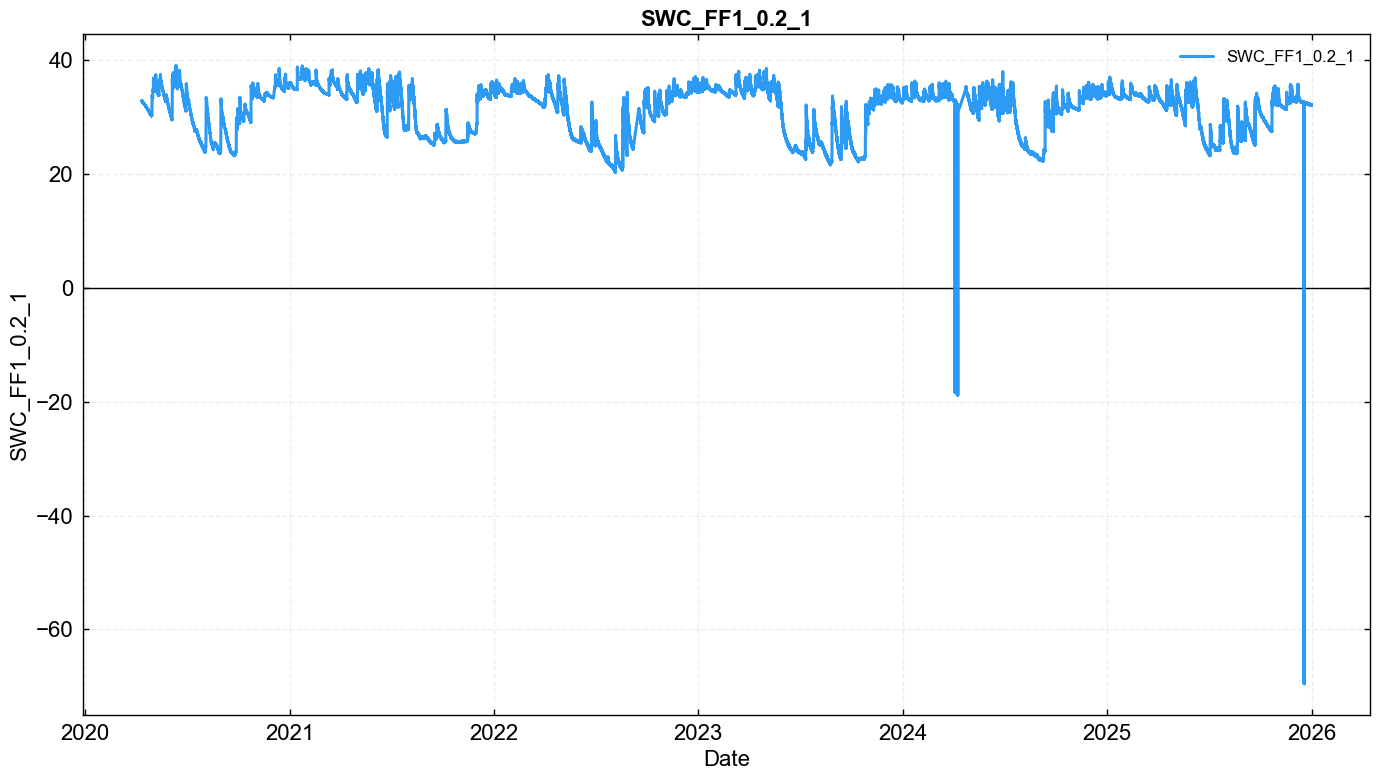

In [12]:
for varname, frame in data_detailed.items():
    dv.plotting.TimeSeries(series=frame[varname]).plot()

## 🔍 Cross-check against the rest of the soil profile
Soil water content has no external reference — no weather service measures the soil at this plot. What it does have is **four other sensors in the same profile**, 5 to 50 cm below the same square metre of forest floor, plus the site's own **precipitation** record. Together those answer the question a single soil sensor cannot answer about itself: *is it still measuring the soil?*

The two failure modes worth separating:

- **it stops reporting** — communication failures, power loss. Loud and easy: gaps and impossible values, which the screening tests below remove.
- **it stops being coupled to the soil** — the soil shrinks away from the prongs in a dry summer, a root grows into the measurement volume, the backfill settles. This one is **quiet**: the series stays inside the physical range, stays smooth, and drifts plausibly. No statistical outlier test can see it. What gives it away is that the sensor no longer *responds*: rain falls, every deeper sensor wets up, and this one does not move.

> **What this can and cannot tell you.** The depths are not replicates — a 5 cm sensor legitimately dries faster, wets first, and swings harder than a 50 cm sensor, so the levels differ and the correlations are far from 1. What is *not* legitimate is a shallow sensor sitting still while the layers underneath it wet up: water reaches 20 cm by passing through 5 cm first. Use the section to *find candidate periods*, then confirm each one against the fieldbook before putting it in `REMOVE_DATES`.

*Sources: the FF1 soil profile (this site) and the screened precipitation product of notebook `30_PRODUCTS/08`.*

In [13]:
def to_30min_mean(series: pd.Series, min_coverage: float = 0.5,
                  max_step: pd.Timedelta = pd.Timedelta('10min')) -> pd.Series:
    """Resample a high-res series to 30MIN means on the end-labelled grid.

    Uses the same end-labelled convention as the database: the period ending at T
    holds the records in (T-30min, T].

    A plain record count cannot decide whether a half hour is well covered here,
    because the raw spacing changes over the record (10MIN before the 2021 logger
    rebuild, 1MIN after) - three records mean full coverage in the first era and
    a 90% gap in the second. Each record is therefore credited with the time it
    represents, i.e. the distance back to the previous record, capped at
    *max_step* so the first record after a long gap cannot claim the whole gap.
    A half hour is returned only when the records present cover at least
    *min_coverage* of it, otherwise NaN - so a gap never masquerades as data.
    """
    if series.empty:
        raise ValueError('to_30min_mean got an empty series')
    spacing = series.index.to_series().diff()
    step = spacing.median()
    if pd.isna(step) or step > pd.Timedelta('30min'):
        raise ValueError(f'cannot resample to 30MIN from a {step} series')
    represented = spacing.clip(upper=max_step).fillna(step)
    grouper = pd.Grouper(freq='30min', label='right', closed='right')
    means = series.groupby(grouper).mean()
    coverage = represented.groupby(grouper).sum() / pd.Timedelta('30min')
    return means.where(coverage >= min_coverage)


def report_blocks(index, label: str, maxgap: str = '1D', note=None):
    """Group a DatetimeIndex of hits into contiguous blocks and print them
    ready to paste into REMOVE_DATES."""
    if len(index) == 0:
        print(f'{label}: none')
        return
    hits = pd.Series(index=pd.DatetimeIndex(index), data=1).sort_index()
    grp = (hits.index.to_series().diff() > pd.Timedelta(maxgap)).cumsum()
    print(f'{label}: {grp.nunique()} period(s)')
    for _, blk in hits.groupby(grp):
        comment = '' if note is None else f'  # {note(blk.index)}'
        print(f"    ['{blk.index[0]:%Y-%m-%d %H:%M:%S}', '{blk.index[-1]:%Y-%m-%d %H:%M:%S}'],{comment}")

#### Negative control
`to_30min_mean` would happily return a series of NaN if handed something that is not high-resolution — silently producing an "empty" comparison that looks like a data gap. Prove it raises instead.

In [14]:
for _bad, _why in [(pd.Series(dtype=float, index=pd.DatetimeIndex([])), 'empty series'),
                   (pd.Series([1.0, 2.0, 3.0],
                              index=pd.date_range('2020-01-01', periods=3, freq='1h')),
                    'already coarser than 30MIN')]:
    try:
        to_30min_mean(_bad)
    except ValueError as e:
        print(f'PASSED - {_why} raises: {e}')
    else:
        raise AssertionError(f'(!) FAILED - to_30min_mean accepted {_why}')

PASSED - empty series raises: to_30min_mean got an empty series
PASSED - already coarser than 30MIN raises: cannot resample to 30MIN from a 0 days 01:00:00 series


### Read the companion depths from the profile file
The other four depths, over the same period, read from the shared raw-profile file
`SWC_FF1_PROFILE_RAW_2020-2025.parquet` written by [`SWC_FF1_PROFILE_2020-2025.ipynb`](SWC_FF1_PROFILE_2020-2025.ipynb). They used to be downloaded here, from the raw bucket, once per depth notebook — the *same* five raw series pulled five times over. Downloading them once into a shared file and reading that file here is enough. They are reduced to 30MIN means immediately and the high-resolution frame is dropped again — the cross-check needs half-hourly means, not four more million-record frames in memory.

**The screened variable itself is still downloaded from the database** (the *Download* section above) and is deliberately *not* taken from this file: `StepwiseMeteoScreeningDb` needs the database tags — units, gain, offset, positions, data version — that `data_detailed` carries and a values-only file does not.

The file holds the **raw, unscreened** series, exactly as the old download did. That is precisely why the 5 cm probe's decoupled window 2020-08-01 → 2020-10-24 (removed in its own notebook, not here) still has to be masked out of the companion reference below.

In [15]:
# The companion depths are read from the pre-downloaded profile file rather than pulled
# from the database again: they are the same five raw series in every depth's notebook,
# so downloading them once is enough. Produced by SWC_FF1_PROFILE_2020-2025.ipynb.
# The screened variable is NOT taken from here - it comes from the database download
# above, because screening needs the database tags this file does not carry.
_profile_raw = pd.read_parquet(PROFILE_PRODUCT)
assert _profile_raw.index.name == 'TIMESTAMP_END', (
    f'(!) {PROFILE_PRODUCT} is not indexed on TIMESTAMP_END')
_absent = [_v for _v in COMPANION_FIELDS if _v not in _profile_raw.columns]
assert not _absent, (
    f'(!) profile file lacks companion column(s) {_absent} - re-run SWC_FF1_PROFILE_2020-2025.ipynb')
# Trim to exactly the screened period ([START, STOP), STOP excluded) so the cross-check
# cannot silently use a wider record than the one being screened.
_profile_raw = _profile_raw.loc[(_profile_raw.index >= pd.Timestamp(START))
                                & (_profile_raw.index < pd.Timestamp(STOP))]
assert not _profile_raw.empty, (
    '(!) profile file holds no records inside [START, STOP) - is it stale?')
print(f'profile file: {_profile_raw.shape[0]} records, '
      f'{_profile_raw.index[0]} -> {_profile_raw.index[-1]}')

# Target first, then the companions ordered by depth: one 30MIN frame for the whole profile.
prof = pd.DataFrame({FIELD: to_30min_mean(data_detailed[FIELD][FIELD].dropna())})
for _v in COMPANION_FIELDS:
    _series = _profile_raw[_v].dropna()
    if _series.empty:
        print(f'(!) {_v} has no data in this period and is left out of the cross-check.')
        continue
    prof[_v] = to_30min_mean(_series)
prof = prof.sort_index()

# The companion depths in the profile file are RAW (unscreened), so the 5 cm probe's
# decoupled stretch of Aug-Oct 2020 - removed in its own notebook, not here -
# is still in this frame. Mask it out of the companion set, or it drags the
# profile mean and the rolling-agreement diagnostic down through autumn 2020.
_DECOUPLED_005 = ('2020-08-01', '2020-10-24')
if 'SWC_FF1_0.05_1' in prof.columns and 'SWC_FF1_0.05_1' != FIELD:
    prof.loc[_DECOUPLED_005[0]:_DECOUPLED_005[1], 'SWC_FF1_0.05_1'] = np.nan
COMPANIONS = [c for c in prof.columns if c != FIELD]

del _profile_raw  # the high-res companion frame is not needed again

assert COMPANIONS, '(!) no companion depth available - the cross-check below cannot run'
print(f'profile frame: {prof.shape[0]} half-hours, {prof.index[0]} -> {prof.index[-1]}')
print(f'target: {FIELD} | companions: {COMPANIONS}')

profile file: 2509501 records, 2020-04-10 15:00:00 -> 2026-01-01 00:00:00
profile frame: 100387 half-hours, 2020-04-10 15:00:00 -> 2026-01-01 00:00:00
target: SWC_FF1_0.2_1 | companions: ['SWC_FF1_0.05_1', 'SWC_FF1_0.1_1', 'SWC_FF1_0.3_1', 'SWC_FF1_0.5_1']


### Level, coverage and correlation
First the plain description: how much data each sensor has, where it sits, and how strongly the depths move together. Correlations between depths are expected to be **high but not near-perfect** (r ≈ 0.7-0.9 on daily means) and to *decrease with depth separation* — the 5 cm and 50 cm sensors measure genuinely different things.

In [16]:
print('data coverage per year (fraction of 30MIN periods with a value):')
display(prof.notna().groupby(prof.index.year).mean().round(3))

print('\nlevel and spread over the whole period [% VWC]:')
display(prof.describe().round(2))

print('\ncorrelation of daily means:')
display(prof.resample('D').mean().corr().round(3))

data coverage per year (fraction of 30MIN periods with a value):


,SWC_FF1_0.2_1,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.3_1,SWC_FF1_0.5_1
TIMESTAMP_END,,,,,
2020,1.000,0.680,1.000,1.000,1.000
2021,0.977,0.977,0.977,0.977,0.977
2022,0.972,0.972,0.972,0.972,0.972
2023,0.998,0.998,0.998,0.998,0.998
2024,0.951,0.948,0.950,0.272,0.953
2025,1.000,1.000,1.000,0.828,1.000
2026,1.000,1.000,1.000,1.000,1.000



level and spread over the whole period [% VWC]:


,SWC_FF1_0.2_1,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.3_1,SWC_FF1_0.5_1
count,98585.00,94458.00,98583.00,83666.00,98624.00
mean,31.23,29.88,29.77,27.15,24.12
std,4.11,5.27,5.26,3.51,2.77
min,20.37,-16.90,18.20,19.91,3.96
25%,27.77,25.26,25.29,23.65,20.71
50%,32.83,30.97,31.11,28.48,25.35
75%,34.27,34.21,33.53,29.51,26.25
max,39.03,39.71,54.26,36.41,31.75



correlation of daily means:


,SWC_FF1_0.2_1,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.3_1,SWC_FF1_0.5_1
SWC_FF1_0.2_1,1.000,0.904,0.928,0.891,0.879
SWC_FF1_0.05_1,0.904,1.000,0.910,0.709,0.835
SWC_FF1_0.1_1,0.928,0.910,1.000,0.754,0.849
SWC_FF1_0.3_1,0.891,0.709,0.754,1.000,0.853
SWC_FF1_0.5_1,0.879,0.835,0.849,0.853,1.000


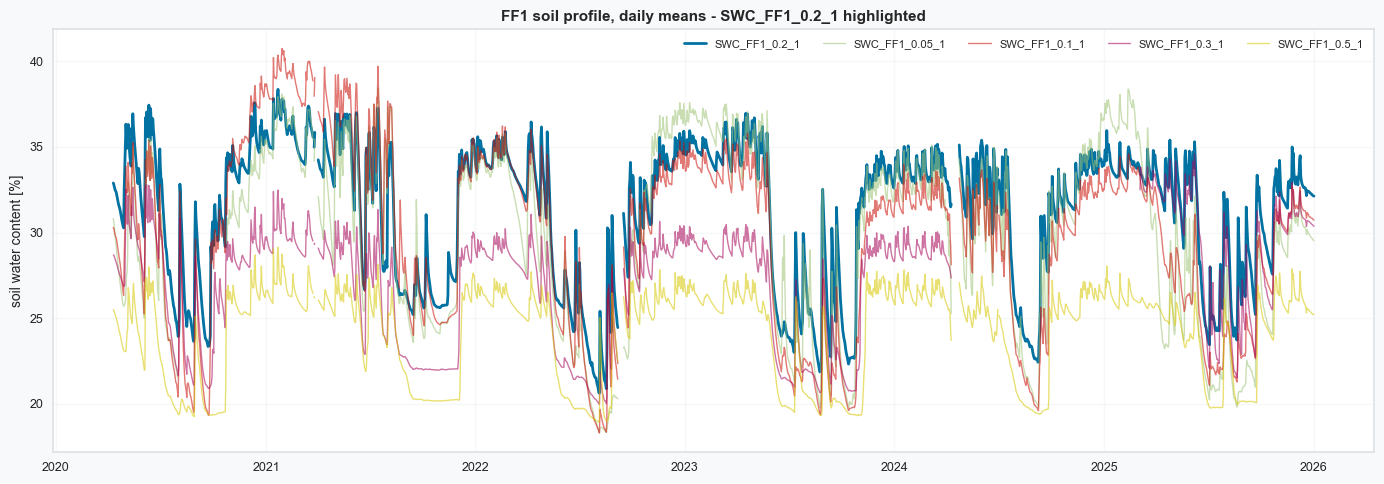

In [17]:
_daily = prof.resample('D').mean()
fig, ax = plt.subplots(figsize=(14, 5))
for _c in prof.columns:
    _lw, _alpha = (2.0, 1.0) if _c == FIELD else (1.0, .55)
    ax.plot(_daily.index, _daily[_c], label=_c, lw=_lw, alpha=_alpha)
ax.set_ylabel('soil water content [%]')
ax.set_title(f'FF1 soil profile, daily means - {FIELD} highlighted')
ax.legend(ncol=len(prof.columns), fontsize=8)
plt.tight_layout()
plt.show()

### Does the target still move with the profile?
Levels differ by depth, so compare **changes** rather than values: the daily change of the target against the daily change of the rest of the profile, correlated in a rolling 30-day window. A well-coupled sensor keeps this high (r ≈ 0.8-0.9); a sensor that has lost contact with the soil keeps producing smooth, in-range values whose *changes* have nothing to do with what the soil is doing, and the rolling correlation collapses.

At 20 cm this diagnostic stays high all five years (yearly-median rolling r ≈ 0.92-0.96). The only two days below 0.3 are isolated single days in Aug 2022 and Aug 2023 — the known false-positive mode, where the whole profile is nearly flat and dividing one tiny change by another collapses r although nothing is wrong. There is **no** sustained decoupling here, unlike the Aug-Oct 2020 episode at 5 cm.

Note too that the **companion set is not constant**: the 0.3 m probe is dead from 23 Apr 2024 to 4 Mar 2025, and its replacement (installed 40 cm down the slope) sits about 3% VWC lower than the old one, so the profile mean is taken over whichever depths are present and steps slightly when 0.3 drops out and returns. The rolling *increment* correlation used here is insensitive to that level step; read the mean's absolute value, not the increment correlation, with the changing membership in mind.

rolling 30-day correlation of daily increments, target vs profile mean:


,count,mean,std,min,25%,50%,75%,max
TIMESTAMP_END,,,,,,,,
2020,246.0,0.91,0.08,0.73,0.89,0.94,0.97,1.00
2021,365.0,0.86,0.15,0.35,0.81,0.94,0.97,0.99
2022,365.0,0.90,0.11,-0.04,0.85,0.94,0.96,1.00
2023,365.0,0.90,0.10,0.26,0.85,0.93,0.98,0.99
2024,343.0,0.93,0.06,0.62,0.92,0.96,0.98,0.99
2025,365.0,0.90,0.09,0.48,0.85,0.92,0.96,0.99
2026,1.0,0.98,NaN,0.98,0.98,0.98,0.98,0.98


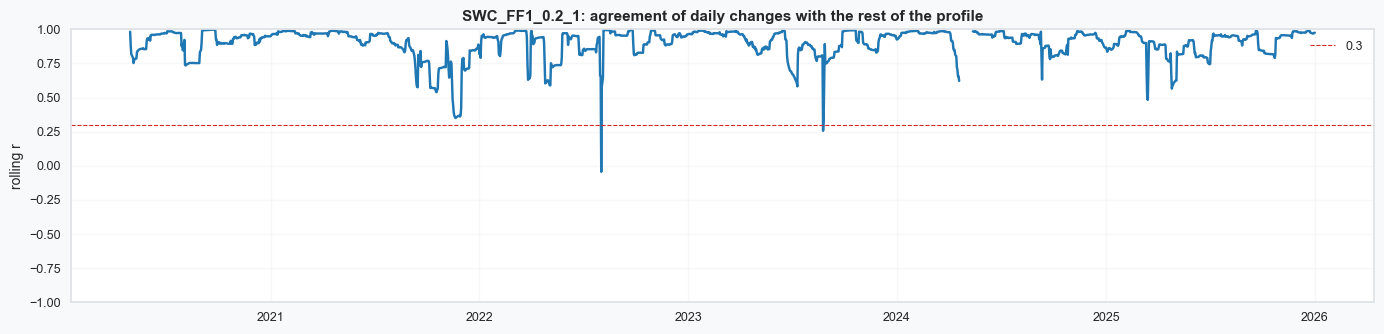

ROLLING AGREEMENT BELOW 0.3: 2 period(s)
    ['2022-08-02 00:00:00', '2022-08-02 00:00:00'],  # 1 day(s)
    ['2023-08-25 00:00:00', '2023-08-25 00:00:00'],  # 1 day(s)


In [18]:
_d_target = _daily[FIELD].diff()
_d_others = _daily[COMPANIONS].mean(axis=1).diff()
rollcorr = _d_target.rolling(30, min_periods=20).corr(_d_others)

print('rolling 30-day correlation of daily increments, target vs profile mean:')
display(rollcorr.groupby(rollcorr.index.year).describe().round(2))

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(rollcorr.index, rollcorr, color='tab:blue')
ax.axhline(0.3, color='tab:red', lw=.8, ls='--', label='0.3')
ax.set_ylim(-1, 1)
ax.set_ylabel('rolling r')
ax.set_title(f'{FIELD}: agreement of daily changes with the rest of the profile')
ax.legend()
plt.tight_layout()
plt.show()

report_blocks(rollcorr[rollcorr < 0.3].index, 'ROLLING AGREEMENT BELOW 0.3', maxgap='3D',
              note=lambda ix: f'{len(ix)} day(s)')

### Does the target still respond to rain?
The sharpest test for the shallowest sensor. For every day with more than 10 mm of precipitation, take the rise of each depth's daily mean over the following two days, and divide the target's rise by the profile mean's. A shallow sensor should give a **ratio at or above 1** — water arrives at 5 cm first. A ratio near **0** while the deeper sensors rise by several percent VWC is physically impossible and means the probe is no longer coupled to the soil.

The summer table is the one to read: that is when soil shrinkage opens gaps around the prongs.

In [19]:
prec = pd.read_parquet(PREC_PRODUCT)[PREC_COL]
prec.index = prec.index + pd.Timedelta('15min')  # TIMESTAMP_MID -> TIMESTAMP_END, as used here
_shared = prof.index.intersection(prec.index)
assert len(_shared) > 0.5 * len(prof), (
    '(!) precipitation product does not line up with the profile - check the timestamp shift')
print(f'precipitation: {prec.index[0]} -> {prec.index[-1]}, '
      f'{len(_shared) / len(prof) * 100:.1f}% of the profile period covered')

_dprec = prec.reindex(prof.index).resample('D').sum(min_count=40)
_events = _dprec[_dprec > 10].index

_rows = []
for _day in _events:
    _before = _daily.loc[:_day - pd.Timedelta('1D')].tail(1)
    _after = _daily.loc[_day:_day + pd.Timedelta('2D')]
    if _before.empty or _after.empty:
        continue
    _resp = _after.max() - _before.iloc[0]
    _resp['PREC'] = _dprec.loc[_day]
    _rows.append(_resp.rename(_day))
resp = pd.DataFrame(_rows)
resp['RATIO'] = resp[FIELD] / resp[COMPANIONS].mean(axis=1)
print(f'\n{len(resp)} rain events > 10 mm/day in the screened period')

print('\nmedian rise per depth [% VWC] after a > 10 mm day, per year:')
display(resp.groupby(resp.index.year).median().round(2))

print('\nmedian response ratio (target / profile mean), all events and summer only:')
_summer = resp[resp.index.month.isin([7, 8, 9, 10])]
display(pd.DataFrame({'all events': resp['RATIO'].groupby(resp.index.year).median(),
                      'Jul-Oct': _summer['RATIO'].groupby(_summer.index.year).median(),
                      'n events': resp['RATIO'].groupby(resp.index.year).size()}).round(2))

precipitation: 2004-01-01 00:30:00 -> 2026-01-01 00:00:00, 100.0% of the profile period covered

198 rain events > 10 mm/day in the screened period

median rise per depth [% VWC] after a > 10 mm day, per year:


,SWC_FF1_0.2_1,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.3_1,SWC_FF1_0.5_1,PREC,RATIO
2020,2.11,1.69,2.95,2.06,0.69,14.4,0.98
2021,1.62,1.95,2.00,1.67,1.21,13.8,0.90
2022,1.45,1.17,1.57,1.32,1.43,13.9,1.07
2023,1.44,2.93,1.31,0.70,0.29,14.6,1.29
2024,1.92,2.32,1.73,0.94,0.59,15.5,1.10
2025,2.25,2.07,1.42,3.04,1.09,15.7,1.24



median response ratio (target / profile mean), all events and summer only:


,all events,Jul-Oct,n events
2020,0.98,1.03,20
2021,0.90,0.89,36
2022,1.07,1.11,30
2023,1.29,1.86,32
2024,1.10,1.21,39
2025,1.24,1.26,41


### Candidate periods for `REMOVE_DATES`
Four scans, each for a different failure mode. All of them produce **candidates only** — check each against the fieldbook and against the plots above before removing anything.

In [20]:
_target_hires = data_detailed[FIELD][FIELD].dropna()

report_blocks(_target_hires[(_target_hires < SWC_MIN) | (_target_hires > SWC_MAX)].index,
              f'OUTSIDE THE PHYSICAL RANGE [{SWC_MIN}, {SWC_MAX}] %', maxgap='1D',
              note=lambda ix: f'{len(ix)} record(s)')

_cov = prof[FIELD].notna().resample('D').mean()
report_blocks(_cov[_cov < 0.9].index, 'DAILY COVERAGE BELOW 90%', maxgap='2D',
              note=lambda ix: f'{len(ix)} day(s)')

report_blocks(rollcorr[rollcorr < 0.3].index, 'NOT MOVING WITH THE PROFILE (rolling r < 0.3)',
              maxgap='3D', note=lambda ix: f'{len(ix)} day(s)')

# A stuck sensor repeats one value. Runs are measured in *time*, not in records,
# because a record means ten minutes in the early era and one minute in the late one.
# Stored precision also changed: until the logger software update of 21 Apr 2020 the
# values arrived in steps of 0.1%, so during a slow dry-down they legitimately hold the
# same rounded value for hours. The threshold below is therefore loose, and the maxima
# printed with it are the more informative numbers.
_runs = (_target_hires != _target_hires.shift()).cumsum()
_spans = _target_hires.groupby(_runs).apply(lambda x: x.index[-1] - x.index[0])
_ends = _target_hires.groupby(_runs).apply(lambda x: x.index[-1])
_sizes = _target_hires.groupby(_runs).size()
_stuck = _spans[_spans >= pd.Timedelta('24h')]
print(f'IDENTICAL-VALUE RUNS LASTING >= 24 h: {len(_stuck)}')
for _g in _stuck.index:
    print(f"    ['{_ends.loc[_g] - _spans.loc[_g]:%Y-%m-%d %H:%M:%S}', "
          f"'{_ends.loc[_g]:%Y-%m-%d %H:%M:%S}'],  # {_sizes.loc[_g]} identical records")
for _label, _mask in [('whole record', _spans.notna()),
                      ('1MIN era only', _ends > pd.Timestamp('2021-03-27'))]:
    _sub = _spans[_mask]
    print(f'   longest identical-value run, {_label}: {_sub.max()} '
          f'(ending {_ends.loc[_sub.idxmax()]})')

print('\n(Copy any confirmed period into REMOVE_DATES below. Check the fieldbook first.)')

OUTSIDE THE PHYSICAL RANGE [0, 60] %: 3 period(s)
    ['2024-04-03 17:09:00', '2024-04-05 18:04:00'],  # 5 record(s)
    ['2024-04-07 07:07:00', '2024-04-08 18:58:00'],  # 7 record(s)
    ['2025-12-18 17:45:00', '2025-12-19 10:39:00'],  # 7 record(s)
DAILY COVERAGE BELOW 90%: 6 period(s)
    ['2021-03-24 00:00:00', '2021-04-02 00:00:00'],  # 10 day(s)
    ['2022-09-06 00:00:00', '2022-09-16 00:00:00'],  # 11 day(s)
    ['2023-06-15 00:00:00', '2023-06-15 00:00:00'],  # 1 day(s)
    ['2024-04-04 00:00:00', '2024-04-23 00:00:00'],  # 19 day(s)
    ['2024-06-29 00:00:00', '2024-07-01 00:00:00'],  # 3 day(s)
    ['2024-10-16 00:00:00', '2024-10-16 00:00:00'],  # 1 day(s)
NOT MOVING WITH THE PROFILE (rolling r < 0.3): 2 period(s)
    ['2022-08-02 00:00:00', '2022-08-02 00:00:00'],  # 1 day(s)
    ['2023-08-25 00:00:00', '2023-08-25 00:00:00'],  # 1 day(s)
IDENTICAL-VALUE RUNS LASTING >= 24 h: 1
    ['2020-04-14 12:10:00', '2020-04-15 13:40:00'],  # 154 identical records
   longest identical

### Adjudicate the candidates against the fieldbook
A candidate period means nothing until it is matched against what happened at the site. The GIN
fieldbook export is read here directly, so the adjudication written up below can be re-run and
challenged rather than taken on trust.

Filtering on the SWC device tags alone would miss most of it: the entries that explain these periods
are power-supply and logger entries carrying no soil device at all. The filter therefore also takes
anything at this profile's location, its logger/DAQ, or a free-text mention of soil, power, logger
or SDI-12.

In [21]:
import html
import re

_fb = pd.read_csv(FIELDBOOK, encoding='utf-8-sig')
_fb.columns = [c.strip() for c in _fb.columns]
_fb['date'] = pd.to_datetime(_fb['Date'], format='%d.%m.%Y', errors='coerce')
assert _fb['date'].notna().all(), '(!) unparsed dates in the fieldbook - check the date format'


def _plaintext(s):
    """GIN stores the entry body as HTML; strip the tags and entities."""
    return re.sub(r'\s+', ' ',
                  html.unescape(re.sub(r'<[^>]+>', ' ', str(s))).replace('\xa0', ' ')).strip()


_fb['text'] = _fb['Text'].map(_plaintext)
_mask = (_fb['Operation Tag'].astype(str).str.contains(r'SWC|iDL_FF1|iDAQ_FF1', case=False, na=False)
         | _fb['Location'].astype(str).str.contains(PROFILE, case=False, na=False)
         | _fb['text'].str.contains(r'soil|SWC|Teros|SDI|power|logger', case=False, na=False))
fb = (_fb[_mask & _fb['date'].between(START, STOP)]
      .drop_duplicates(subset=['date', 'Event Tag', 'Text'])
      .sort_values('date'))
assert len(fb) > 0, '(!) no fieldbook entries matched - has the export format changed?'
print(f'fieldbook: {len(_fb)} entries total, '
      f'{len(fb)} relevant to {PROFILE} within the screened period')


def fieldbook_near(start, stop=None, days: int = 3, maxchars: int = 220):
    """Print the fieldbook entries within *days* of a period."""
    start = pd.Timestamp(start)
    stop = pd.Timestamp(stop) if stop is not None else start
    hits = fb[fb['date'].between(start - pd.Timedelta(days=days), stop + pd.Timedelta(days=days))]
    if hits.empty:
        print(f'   (no fieldbook entry within +/-{days} days)')
        return
    for _, r in hits.iterrows():
        print(f"   {r['date']:%Y-%m-%d} {r['Event Tag']:<12s} {r['text'][:maxchars]}")

fieldbook: 2102 entries total, 129 relevant to FF1 within the screened period


In [22]:
# One entry per candidate period found by the scans above, rebuilt from THIS depth's
# own scan output (not carried over from the 5 cm notebook). It is the record of what
# was adjudicated for the 20 cm sensor.
CANDIDATES = [
    ('2021-03-24', '2021-04-02', 'coverage gap (logger rebuild)'),
    ('2022-08-02', '2022-08-02', 'rolling-agreement dip, single day (flat-profile noise)'),
    ('2022-09-06', '2022-09-16', 'coverage gap (FF1 power supply)'),
    ('2023-06-15', '2023-06-15', 'coverage gap (FF1 power incident)'),
    ('2023-08-25', '2023-08-25', 'rolling-agreement dip, single day (flat-profile noise)'),
    ('2024-04-03', '2024-04-23', 'coverage gap + out-of-range values (SDI-12 bus failure)'),
    ('2024-06-29', '2024-07-01', 'coverage gap (station-wide outage)'),
    ('2024-10-16', '2024-10-16', 'coverage gap (station-wide outage)'),
    ('2025-02-27', '2025-07-06', 'fieldbook incident window (names TS_FF1_02_1)'),
    ('2025-12-18', '2025-12-19', 'out-of-range values (remote logger uploads)'),
]
for _start, _stop, _why in CANDIDATES:
    print(f'\n--- {_start} -> {_stop}  ({_why})')
    fieldbook_near(_start, _stop, days=3)



--- 2021-03-24 -> 2021-04-02  (coverage gap (logger rebuild))
   2021-03-24 HW_MOD       Installed new box with datalogger und multiplexer
   2021-03-24 TRASHED      Device trashed
   2021-03-24 HW_MOD       Shutdown the FF1 logger and all components for reconstruction of the logger box. We kept the naming of all variable where we didn't replaced the sensors by new sensor (type). Since we never added the location "box" to th
   2021-03-24 ADD          Added new device to site. The sensor is installed right besides the Soil Heat Flux plate G_FF1_0.05_1
   2021-03-24 ADD          Added new device to site. The sensor is installed right besides the Soil Heat Flux plate G_FF1_0.05_2
   2021-03-24 TRASHED      Device trashed. Removed the multiplexer and will recycle them. Some relays didn't work any more.
   2021-03-25 ADD          Added new device to location. Installed the freshly calibrated CR1000 together with the new box (including the new multiplexers and terminals) at FF1
   2021-03-

#### How to read the candidate list

The outcome for `SWC_FF1_0.2_1`, read off the cell above and the scans that produced it:

- **Out of physical range** — 19 records, **all in the 1MIN era** (none in the back-filled 10MIN
  era), in two documented clusters: the April 2024 SDI-12 bus failure (12 records) and the two
  remote logger-program uploads of 18-19 Dec 2025 (7 records). Every value is a fixed negative
  sentinel (−13.9 to −18.9, and −69.6 during the December uploads), never a run — the failed-SDI-12
  signature once each sensor's calibration has been applied. They are removed **without
  hand-adjudication**, and by two mechanisms rather than one: **11 of the 19** sit in the stray
  2/3/5/6-minute (and isolated) frequency groups that the logger trouble produced, so diive discards
  them together with those groups before screening starts (April 2024: 6, December 2025: 5); the
  remaining **8** are removed by the **absolute-limits test** (April 2024: 6, December 2025: 2).
  Either way the rule is physical and needs no adjudication. Removing them costs no half-hourly value:
  each of the 8 that reaches absolute limits is an isolated minute leaving 6-29 in-range 1MIN records
  in its 30MIN bin, so no half hour is emptied.
- **Coverage below 90%** — six periods, and every one matches a documented profile-wide event:
  the 2021 logger rebuild, the 10-day FF1 power-supply failure of Sep 2022, the one-day FF1 power
  incident of 15 Jun 2023, the April 2024 SDI-12 bus failure (ended by unplugging the 0.3 m probe on
  23 Apr), and the two station-wide outages of 2024-06-29 → 07-01 (44 h) and 2024-10-16 (8 h) that
  have no fieldbook entry but appear in every variable (the first is the same gap notebook
  `30_PRODUCTS/08` found in precipitation). Gaps need no removal — they are already missing.
- **Not moving with the profile** — only two isolated single days (2022-08-02, 2023-08-25), both the
  flat-profile false positive described above (near-zero daily changes divided by near-zero daily
  changes). No sustained loss of coupling at any point in five years. **Kept.**
- **Identical-value runs** — one run lasting ≥ 24 h, on 2020-04-14/15 (value 32.4% held for
  25.5 h), and it sits squarely in the **11 days between 2020-04-10 and 2020-04-21** when values
  arrived in steps of 0.1% VWC (18 distinct values in 1,589 records). That ends with the fieldbook
  entry of 2020-04-21, *"New datalogger software with two byte precision for the soil profile
  measurement (Teros 12 and 21)"*: right after it the record carries full float precision (333
  distinct values in the next 336 records) and the long runs stop for good. A storage-resolution
  artefact, not a stuck sensor — the values are usable, just coarse. In the 1MIN era no value ever
  repeats for more than **two minutes**.
- **The 27 Feb → 6 Jul 2025 fieldbook window** — the one incident logged at this location. The entry
  is filed under the SWC device but names `TS_FF1_02_1`, the co-located soil **temperature** sensor,
  and reads *"does not work regularly since 27.02"*, closed 6 Jul with *"the sensor is working fine"*.
  The soil-**water** record is untouched across the whole window: median 1,440 records/day (only
  2025-03-04 at 1,439 and 2025-04-10 at 1,411), zero out-of-range, zero missing, longest flat run
  two minutes, and a smooth seasonal dry-down (monthly mean 33.9 → 33.6 → 33.0 → 32.4 → 29.1 → 26.0%
  from Feb to Jul, in line with every prior year) with an intact rain response (2025 ratio 1.24).
  **This depth's SWC probe was fine; the incident was the temperature sensor.** Nothing to remove.

So nothing here is a wrong-but-plausible value: the failed reads are physical (absolute limits), the
gaps are already missing, the flat run is a storage artefact, the rolling-agreement dips are noise,
and the 2025 incident was the co-located temperature sensor. `REMOVE_DATES` is therefore **empty**.

## ▶️ Start MeteoScreening with `diive`

> Validating data for variable SWC_FF1_0.2_1 ...

> Found 6 unique frequencies across 2504109 records.

> Found frequencies:

> The following frequencies will be used: [60.0, 600.0] (seconds)

> Note that there is more than one single time resolution and all data will be upsampled to match 
the highest found time resolution (60.0S).

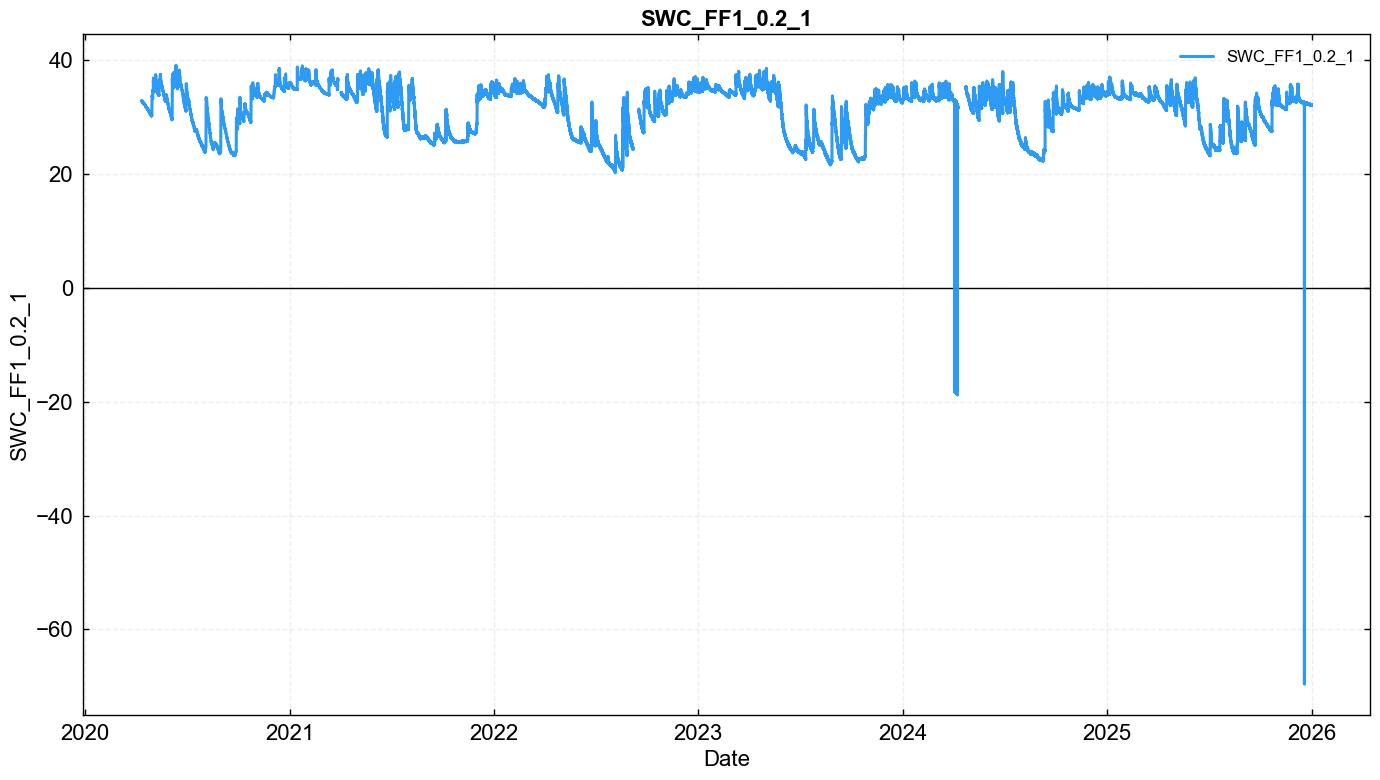

In [23]:
mscr = dv.qaqc.StepwiseMeteoScreeningDb(
    site=SITE,
    data_detailed=data_detailed,
    fields=FIELDS,
    site_lat=SITE_LAT,
    site_lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
)
mscr.showplot_orig()

## 🔍 Outlier detection
Run a test → inspect its preview → commit with `mscr.addflag()`. Only the committed flag of the **most recent** test is added. Skip any test a variable does not need.

**What soil water content needs, and what it does not.** The series is smooth, strongly autocorrelated, and seasonally non-stationary: it ranges over more than 15 percentage points between a wet winter and a dry summer at this depth, and the wet and dry extremes are the most interesting values in it, not the least trustworthy. Two consequences run through this whole section:

- **Never split day and night.** Every test below is run with `separate_daytime_nighttime=False`. Soil moisture has no meaningful diurnal cycle at these depths, so a day/night split would only halve the sample of each threshold.
- **Distribution-wide tests do not belong here.** A z-score over the whole record measures how far a value sits from the multi-year mean, which for this variable is a statement about the season, not about data quality. Those tests are listed further down, switched off, with the reasoning.

For the 20 cm sensor the needed list is short: the failed-read sentinels (**absolute limits**) and the **missing-values** flag. **No manual removal is committed** — this depth has no documented or evidence-based fault to remove (see *How to read the candidate list*). No spike test is committed either — see *No spike test is used* below for the measurement that settles it.

In [24]:
mscr.start_outlier_detection()

> Starting step-wise outlier detection for variable SWC_FF1_0.2_1 ...

Plot the current cleaned data at any point during detection:

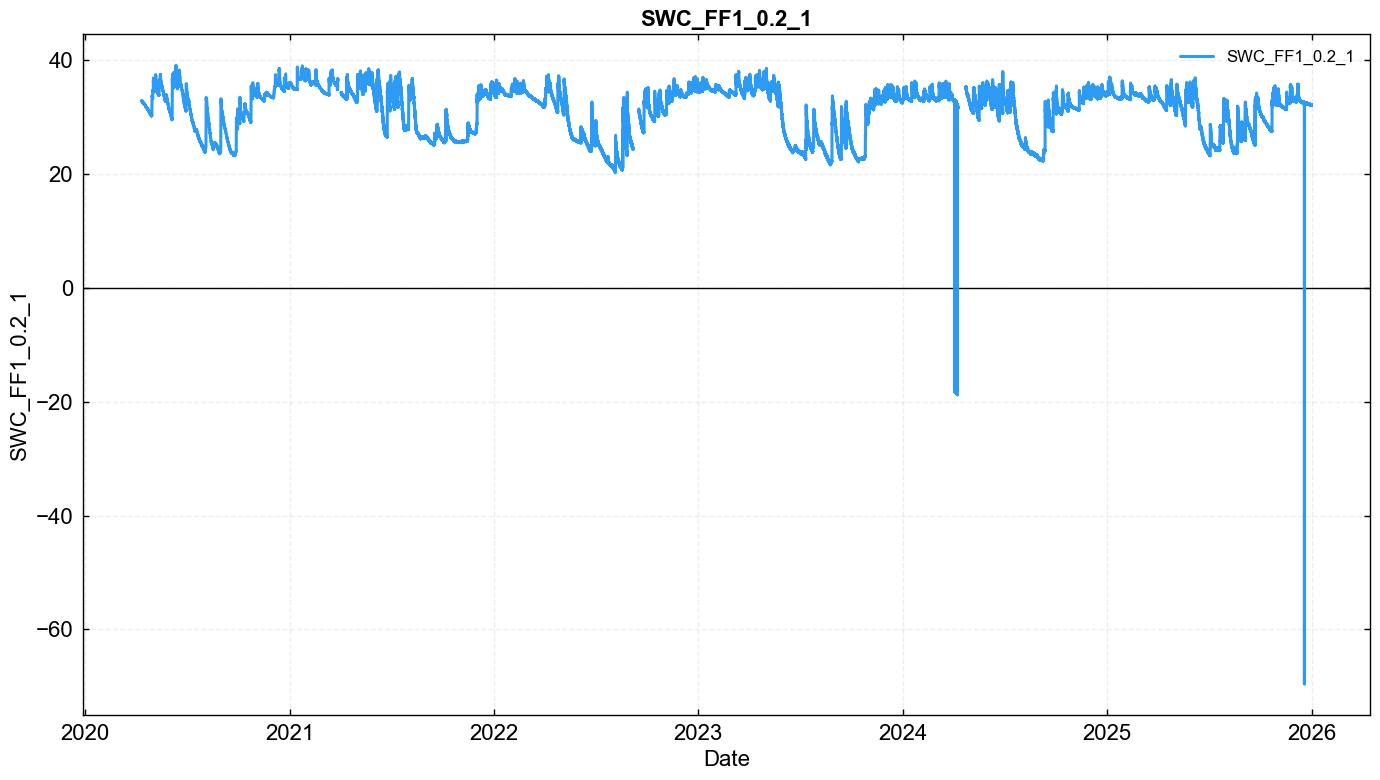

In [25]:
for key, val in mscr.outlier_detection.items():
    val.showplot_cleaned(interactive=False)

### Manual removal
Flag specific timestamps or time ranges for removal — known sensor failures, maintenance windows, etc. Give `[start, stop]` pairs and/or single timestamps.

In [26]:
if SHOW_PARAM_HELP:
    help(dv.outliers.ManualRemoval)

In [27]:
# No manual-removal windows for the 20 cm sensor.
#
# Unlike the 5 cm probe, this depth shows no decoupled-probe episode and no other
# wrong-but-plausible values: the rolling agreement with the profile never sustains
# below 0.3 (only two isolated single-day noise dips, Aug 2022 and Aug 2023), and the
# rain-response ratio is healthy every year (0.90-1.29, median ≈ 1.1). The failed reads
# are caught by absolute limits, the gaps are already missing, the 2020-04 flat run is a
# storage-resolution artefact, and the 27 Feb-6 Jul 2025 fieldbook incident concerned the
# co-located TEMPERATURE sensor (TS_FF1_02_1), not this probe - the SWC record is complete
# and in range right through it (see the closing notes and the candidate-list cell).
#
# Reserve REMOVE_DATES for values that are WRONG BUT PLAUSIBLE - the one class no physical
# rule can catch. A manual window is blunt (it deletes the whole range, not the offending
# minutes), so anything a rule can catch is left to the rule, and anything already missing
# needs nothing. There is no such value at this depth.
REMOVE_DATES = []
if REMOVE_DATES:
    mscr.flag_manualremoval_test(remove_dates=REMOVE_DATES, showplot=True, verbose=True)
else:
    print('No manual removal windows for this depth - skip the addflag cell below.')


No manual removal windows for this depth - skip the addflag cell below.


In [28]:
if REMOVE_DATES:
    mscr.addflag()

### Absolute limits
Flags values outside a fixed physical range `[minval, maxval]`. This is the workhorse test for soil water content: every artefact in this record that is *not* the 2020 decoupling is a failed sensor read, and every failed read lands far outside the physical range.

In [29]:
if SHOW_PARAM_HELP:
    help(dv.outliers.AbsoluteLimits)

> running AbsoluteLimits ...

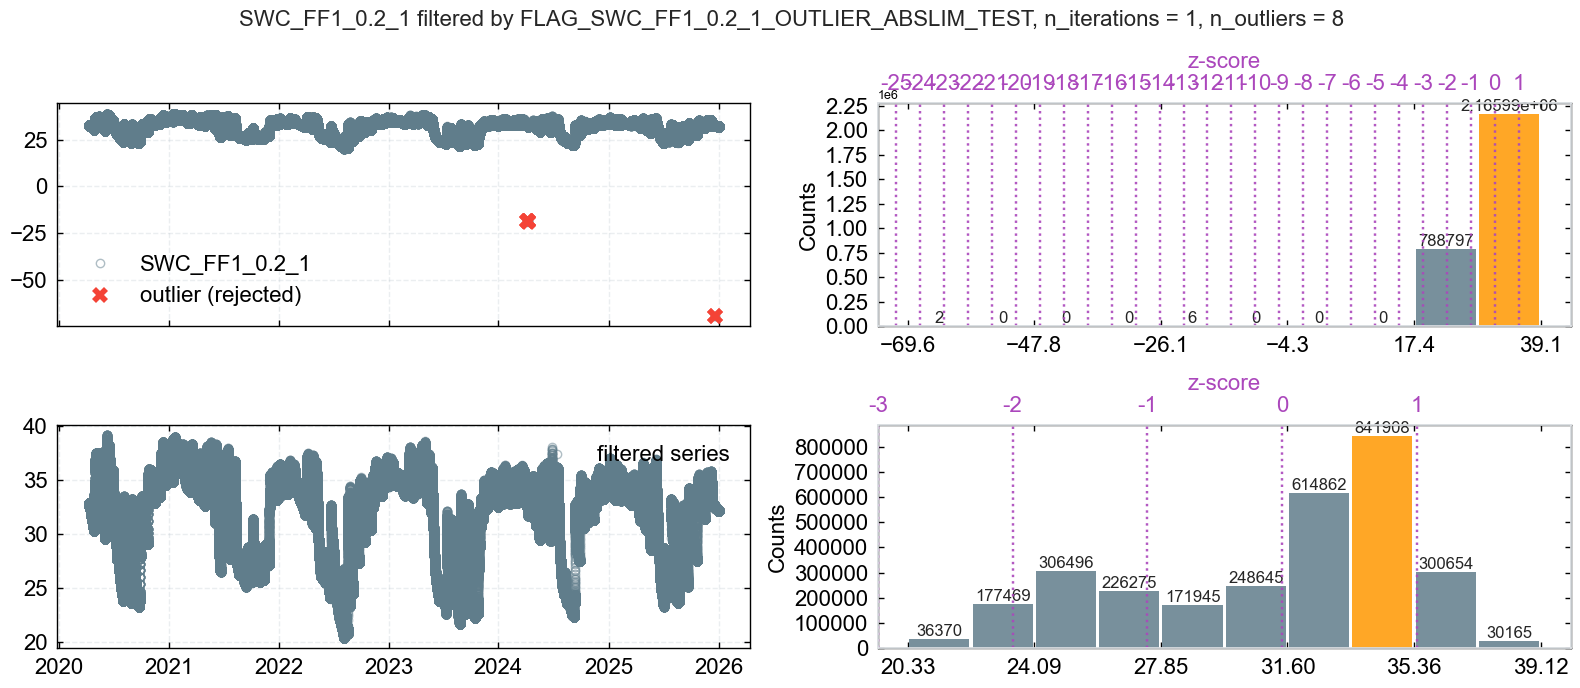

In [30]:
# Volumetric water content in %, so 0 is the hard physical floor. The upper limit is
# deliberately loose: the highest value ever recorded at this depth is 39.0%, well below
# any plausible porosity, so 60 can only fire on something unphysical.
# A failed SDI-12 read enters the record as that sensor's calibration polynomial evaluated
# at zero response, which lands at a fixed negative value per sensor (this depth: -18.3 to
# -18.9 during the April 2024 bus failure, and -69.6 during the Dec 2025 logger uploads) -
# hence a floor of 0 catches all of them and nothing else. Of the 19 out-of-range records
# only 8 reach this test; the other 11 are discarded earlier with the stray/isolated
# frequency groups of April 2024 and December 2025 (diive drops any group below 0.2%).
mscr.flag_outliers_abslim_test(minval=SWC_MIN, maxval=SWC_MAX, showplot=True, verbose=True)


In [31]:
mscr.addflag()

> ++Added flag column FLAG_SWC_FF1_0.2_1_OUTLIER_ABSLIM_TEST to flag data

### No spike test is used, and the Hampel filter is not committed
Every remaining template test (Hampel, z-score, rolling z-score, local SD, increments z-score, local outlier factor, trim low) is **left switched off**. For the 20 cm sensor the case against a spike test is the same as at 5 cm, and it rests on this depth's own numbers.

**The differencing trap is real but no longer catastrophic on the pinned diive.** Run after absolute limits, with a one-day window (`window_length = 60 * 24`), and **reported per era** (never on the total):

| Hampel call | flagged in the 10MIN era | flagged in the 1MIN era |
|---|---|---|
| `use_differencing=True, n_sigma=8`   | 10 (0.00%) | 14 (0.00%) |
| `use_differencing=True, n_sigma=30`  | 2 | 1 |
| `use_differencing=True, n_sigma=100` | 0 | 0 |
| `use_differencing=False, n_sigma=8`  | **6 012 (1.19%)** | **6 869 (0.27%)** |

Two things to read here. First, `n_sigma` now *responds* (24 → 3 → 0 total on the differenced series) instead of being pinned near a fifth of the back-filled era — that is the diive fix for the degenerate-MAD mass rejection working, and it is why this table looks nothing like the pre-fix 5 cm one. Second, the differenced filter still is not safe: at `n_sigma=8` it flags **24 records**, and every one of them is a value you want to keep — **10** sit exactly on the 24-26 Mar 2021 logger-rebuild seam (the 10MIN→1MIN boundary, differencing artefact, 0 mm rain), and the **other 14 all sit inside a rain hour** carrying 8.8-28.6 mm (2022-08-05, 2022-08-20, 2022-08-26, three separate fronts on 2023-07-12, 2024-06-28, 2025-07-27). It removes wetting fronts. The non-differenced call is worse still, deleting 1.19% / 0.27% of real, in-range data by construction.

**There is nothing for a spike test to find.** Once absolute limits has removed the failed reads, the largest remaining minute-to-minute changes in the 1MIN era are real:

- 2023-07-12 12:14, 24.35 → 26.76% in one minute, with 37.6 mm of rain in the surrounding hour (56.9 mm that day) — a wetting front reaching 20 cm, and the level stays up.
- the only *larger* jumps in the whole record are the two gap-recovery edges (2022-09-16 +7.1% and 2024-04-23 +3.6%, both with 0 mm rain), which are the differencing-across-a-gap artefact, not spikes.

The 99.99th percentile of minute-to-minute change is 0.20% VWC; any filter tuned tightly enough to fire on the fronts removes real soil moisture. So no spike test is committed.

The others, for the record: **z-score over the whole record** measures distance from the multi-year mean, which for this variable *is* the season — a wet February and a dry July are both correct. **Rolling z-score / local SD** fight the same physics as Hampel. **Increments z-score** degenerates in the back-filled era exactly as the differenced Hampel would without the fix. **Local outlier factor** is far too slow on 1MIN data. **Trim low** removes a fixed share of low values by construction.

So screening here is: **absolute limits** (physical range) + **missing values**. No manual removal, no spike test.

One practical warning for any test you do try: differencing-based tests compute their differences **after dropping missing records**, so the records flanking every gap are compared across the gap and look like spikes (the two "largest jumps" above are exactly this). This record has a 19-day coverage gap in April 2024 and a 10-day one in September 2022.

If you want to try one anyway, the calls are below. Run it, look at the preview, check what it does to the 2020-2021 era and to the rain days specifically, and only `mscr.addflag()` if it is genuinely removing artefacts.

In [32]:
# Optional, all off by default - read the note above before enabling any of these,
# and check the flagged count per era rather than the total.
# mscr.flag_outliers_hampel_test(window_length=60 * 24, n_sigma=8, use_differencing=False,
#                                separate_daytime_nighttime=False,
#                                repeat=False, showplot=True, verbose=3)
# mscr.flag_outliers_zscore_test(thres_zscore=4.5, separate_daytime_nighttime=False,
#                                repeat=True, showplot=True, verbose=True)
# mscr.flag_outliers_zscore_rolling_test(thres_zscore=4.5, winsize=60 * 24 * 7,
#                                        repeat=True, showplot=True, verbose=True)
# mscr.flag_outliers_localsd_test(n_sd=7, winsize=60 * 24 * 7, constant_sd=False,
#                                 separate_daytime_nighttime=False,
#                                 repeat=False, showplot=True, verbose=True)
# mscr.flag_outliers_increments_zcore_test(thres_zscore=40, repeat=True, showplot=True, verbose=True)
# mscr.addflag()

### Missing values
Not an outlier test — flags missing records so they are counted in the overall `QCF`.

In [33]:
mscr.flag_missingvals_test(verbose=True)

> running MissingValues ...

> MISSING VALUES TEST: Generated new flag variable FLAG_SWC_FF1_0.2_1_MISSING_TEST, newly 
calculated from variable SWC_FF1_0.2_1, with flag 0 (good values) where SWC_FF1_0.2_1 is available, 
flag 2 (bad values) where SWC_FF1_0.2_1 is missing.

### Overall quality flag QCF
Aggregate all committed test flags into one overall flag `QCF` (0 = good, 1 = marginal, 2 = bad) and filter the series. Required before corrections and resampling.

In [34]:
mscr.finalize_outlier_detection()

#### Reports

In [35]:
mscr.report_outlier_detection_qcf_evolution()

====================================================================================================
====================

QCF EVOLUTION: SEQUENTIAL TEST APPLICATION

====================================================================================================
====================

Shows how QCF flag distribution changes as tests are applied sequentially

Target variable: SWC_FF1_0.2_1

...

(count)      (count)                          
0/1/2

----------------------------------------------------------------------------------------------------
--------------------

1     SWC_FF1_0.2_1_MISSING                  0        2954797      0            100.00    0.00      
2954797/0/0

2     SWC_FF1_0.2_1_OUTLIER_ABSLIM           8        2954789      8            100.00    0.00      
2954789/0/8

====================================================================================================
====================

In [36]:
mscr.report_outlier_detection_qcf_flags()

════════════════════════════════════════════════════════════════════════════════════════════════════

INDIVIDUAL TEST FLAG STATISTICS: SWC_FF1_0.2_1

════════════════════════════════════════════════════════════════════════════════════════════════════

Total test flags: 2

┌─ REPORT 1A: ALL RECORDS (INCLUDING MISSING VALUES)

...

├─ SWC_FF1_0.2_1_OUTLIER_ABSLIM

│  Period          │ Pass (0)        │ Warn (1)        │ Fail (2)        │ Missing

│  -------------------------------------------------------------------------------------

│  OVERALL         │ 2954789 (100.0%) │     0 (  0.0%)  │     8 (  0.0%)  │    0 (  0.0%)

════════════════════════════════════════════════════════════════════════════════════════════════════

In [37]:
mscr.report_outlier_detection_qcf_series()

======================================================================

QCF QUALITY CONTROL REPORT: SWC_FF1_0.2_1

======================================================================

[1] TIME PERIOD

Start:  2020-04-10 14:50

...

[4] DATA LOSS ANALYSIS

Records retained after QC: 2954789/2954797 (100.00%)

Data loss from QC:         8/2954797 (0.00%)

Final data coverage:       2954789/3011590 (98.11% of potential)

======================================================================

#### Plots

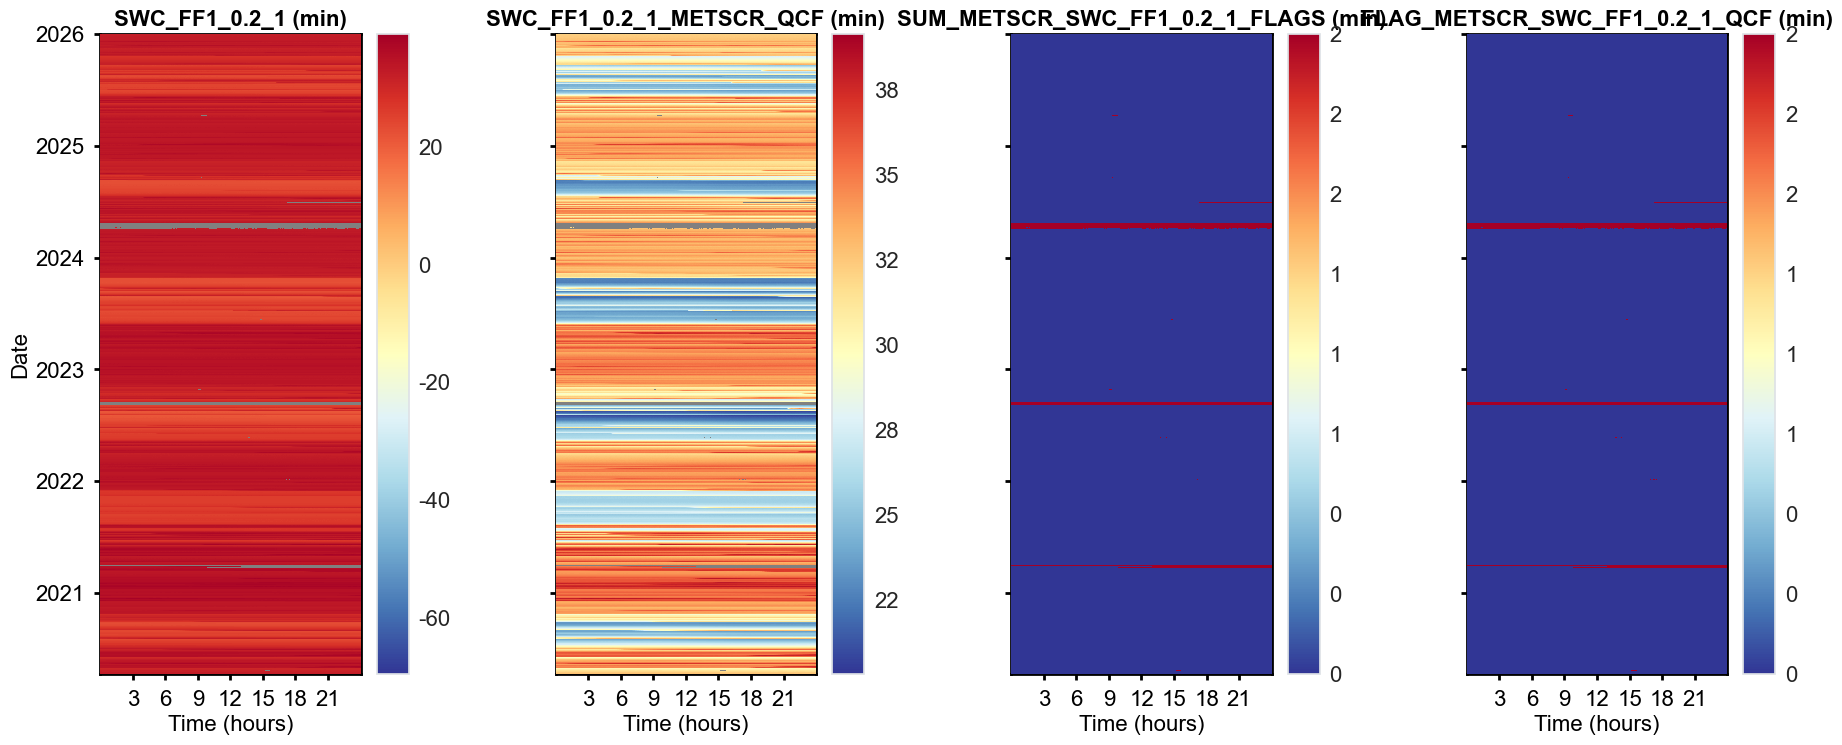

In [38]:
mscr.showplot_outlier_detection_qcf_heatmaps()
# mscr.showplot_outlier_detection_qcf_timeseries()

## 🔧 Corrections
Applied to the high-res, QCF-filtered data. **None of them apply to soil water content**, and all calls below stay commented out.

The corrections diive offers are offset removals for radiation and relative humidity, threshold clipping, and setting ranges to a constant — every one of them writes a value the sensor did not measure. For this variable there is nothing to correct *within* the series: a probe reading too high or too low is a calibration matter (soil-specific permittivity calibration), which cannot be fixed after the fact from the series itself, and this record carries no decoupled-probe fault to correct or remove in the first place (the Aug-Oct 2020 episode is specific to the 5 cm sensor and does not recur at 20 cm).

> ⚠️ In particular, do **not** clip to a minimum: the failed reads are already gone via absolute limits, and clipping would replace a missing measurement with a fabricated 0% — which reads as "bone dry soil" downstream.

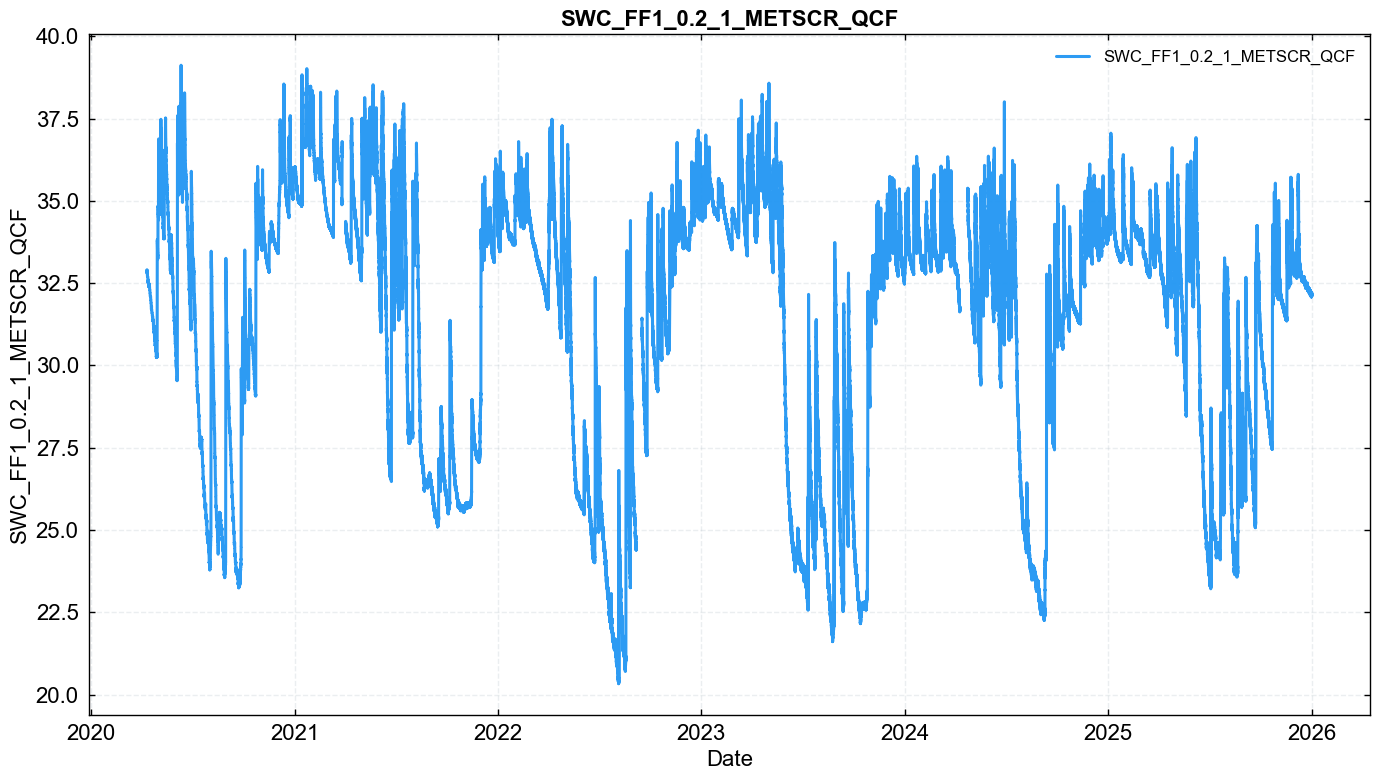

In [39]:
mscr.showplot_cleaned()

Inspect the most frequent values first (read-only, safe to run). For soil water content there should be **no** dominant repeated value: a value appearing thousands of times in the 1MIN era would mean a stuck sensor. Frequent repeats *are* expected in the 2020-2021 part, where each 10MIN reading was back-filled across ten 1MIN slots.

In [40]:
for ff in mscr.fields:
    vc = mscr.series_hires_cleaned[ff].value_counts()
    print(f'--- {ff} (top 20 of {mscr.series_hires_cleaned[ff].count()} records) ---')
    print(vc.head(20))

--- SWC_FF1_0.2_1 (top 20 of 2954789 records) ---
SWC_FF1_0.2_1_METSCR_QCF
32.40000    1940
32.50000    1760
31.60000    1380
31.50000    1330
32.70000    1170
32.10000    1140
32.30000     950
31.70000     840
31.90000     830
32.80000     800
32.90000     730
32.60000     730
32.20000     680
31.80000     630
32.00000     620
31.40000     330
33.74766     138
33.66504     132
33.77656     130
33.92726     130
Name: count, dtype: int64


In [41]:
# All commented out on purpose - none of these apply to soil water content.
# mscr.correction_setto_max_threshold(threshold=60)
# mscr.correction_setto_min_threshold(threshold=0)
# mscr.correction_setto_value(dates=[['2022-04-01', '2022-04-05']], value=0, verbose=1)
# mscr.correction_set_exact_value_to_missing(values=[0])
# mscr.showplot_cleaned(interactive=False)

## 🔁 Resampling

### Resample to 30MIN
Resample the screened high-res series to `RESAMPLING_FREQ`. The output timestamp is `TIMESTAMP_END` again (see *Timestamp convention*), ready for upload.

> running resample_series_to_freq ...

> Resampling data from min to 30min frequency ...

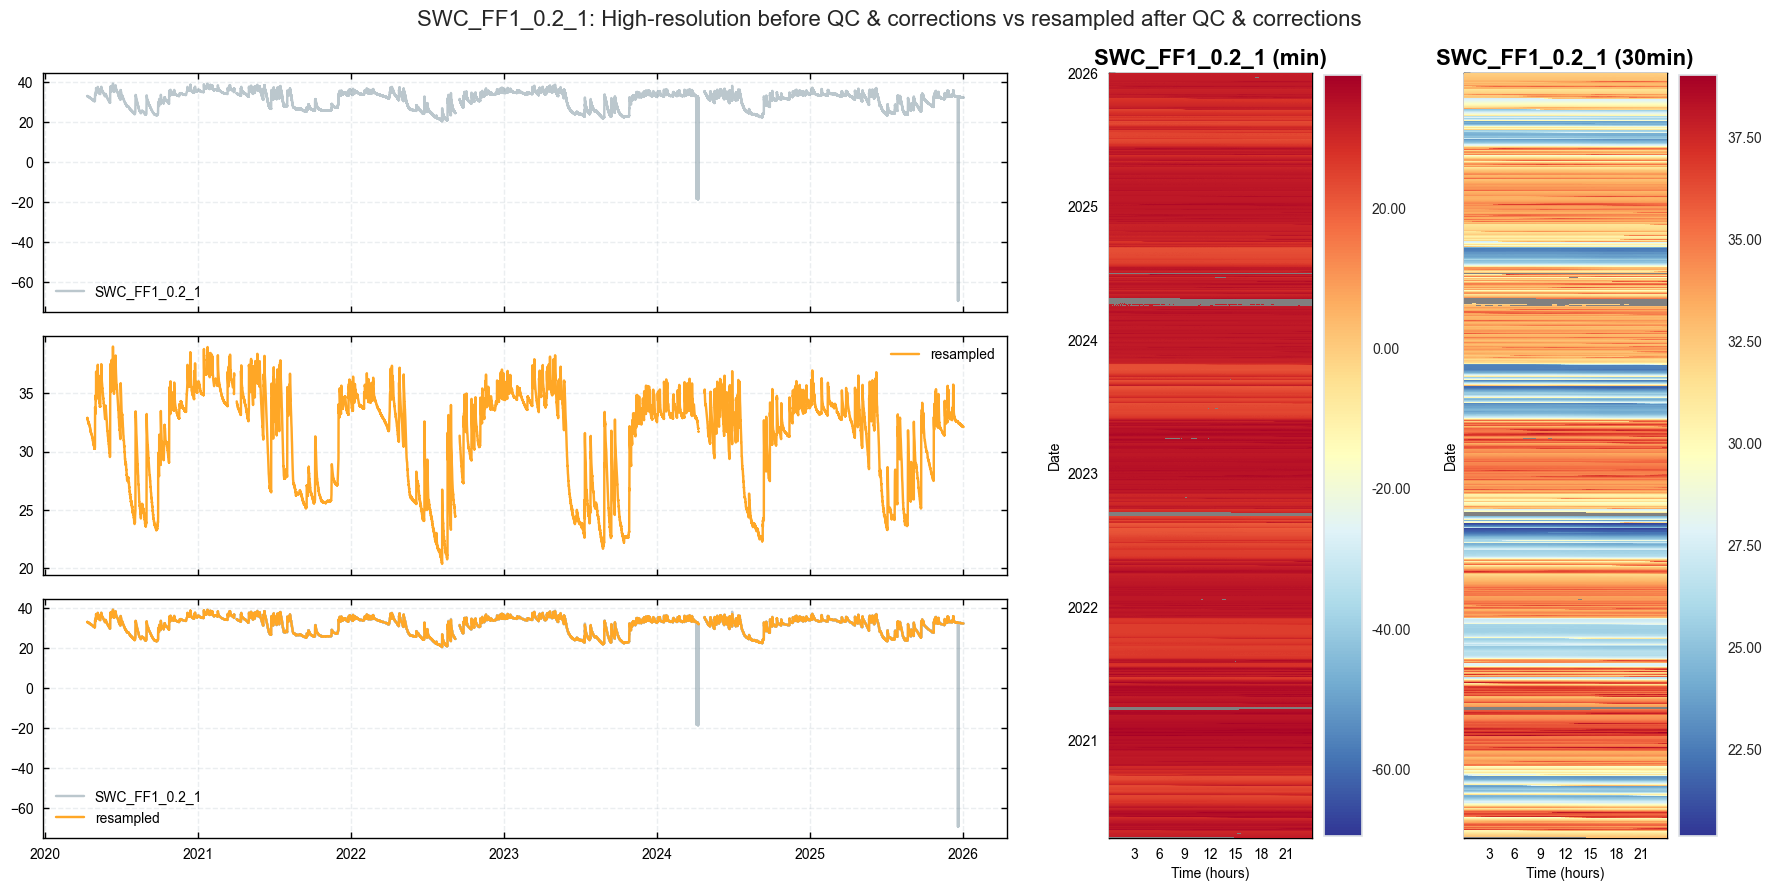

In [42]:
# mincounts_perc stays at the template default of .25, the opposite choice from the
# precipitation notebook. A 30MIN *mean* of a smooth state variable is well estimated
# from a quarter of the records, whereas a *sum* built from a quarter of the records
# under-reports by construction. Requiring near-complete coverage here would throw
# away good half-hours during the April 2024 bus trouble for no gain in accuracy.
mscr.resample(to_freqstr=RESAMPLING_FREQ, agg=RESAMPLING_AGG, mincounts_perc=.25)
mscr.showplot_resampled()

### Check the resampled time resolution

In [43]:
for v in mscr.resampled_detailed.keys():
    freq = dv.times.DetectFrequency(index=mscr.resampled_detailed[v].index, verbose=True).get()
    status = 'PASSED' if freq == RESAMPLING_FREQ else '(!) FAILED'
    print(f'{status} - {v}: {freq}')

> Detect frequency: 30min (all methods agree)

PASSED - SWC_FF1_0.2_1: 30min


### Re-check the screened product against the profile
The same comparison as before screening, now on the resampled 30MIN product. Screening should leave the agreement with the rest of the profile **no worse** than it was — if the correlation drops, a test removed real soil moisture rather than an artefact. Here `REMOVE_DATES` is empty, so only the failed-read sentinels (absolute limits) and the missing-values flag are applied; the agreement should be **essentially unchanged**, not improved — there is no removed decoupling window to recover, unlike at 5 cm. A visible drop would mean absolute limits caught something real, which for a floor of 0% it cannot.

In [44]:
_screened = mscr.resampled_detailed[FIELD][FIELD]

_before = prof.resample('D').mean()
_after = _before.copy()
_after[FIELD] = _screened.resample('D').mean()

r_before = _before[FIELD].diff().corr(_before[COMPANIONS].mean(axis=1).diff())
r_after = _after[FIELD].diff().corr(_after[COMPANIONS].mean(axis=1).diff())
n_before = prof[FIELD].notna().sum()
n_after = _screened.notna().sum()

print(f'{"":18s} {"n 30MIN":>9s} {"r(increments)":>15s} {"mean [%]":>10s}')
print(f'{"before screening":18s} {n_before:9d} {r_before:15.3f} {prof[FIELD].mean():10.2f}')
print(f'{"after screening":18s} {n_after:9d} {r_after:15.3f} {_screened.mean():10.2f}')
print(f'{"removed":18s} {n_before - n_after:9d} '
      f'({(1 - n_after / n_before) * 100:.2f}% of the half-hours that had a value)')

if r_after < r_before - 0.01:
    print('\n(!) WARNING - agreement with the profile got worse. A test may have removed real data.')
else:
    print('\nOK - screening did not degrade agreement with the rest of the profile.')

                     n 30MIN   r(increments)   mean [%]
before screening       98585           0.879      31.23
after screening        98552           0.879      31.23
removed                   33 (0.03% of the half-hours that had a value)

OK - screening did not degrade agreement with the rest of the profile.


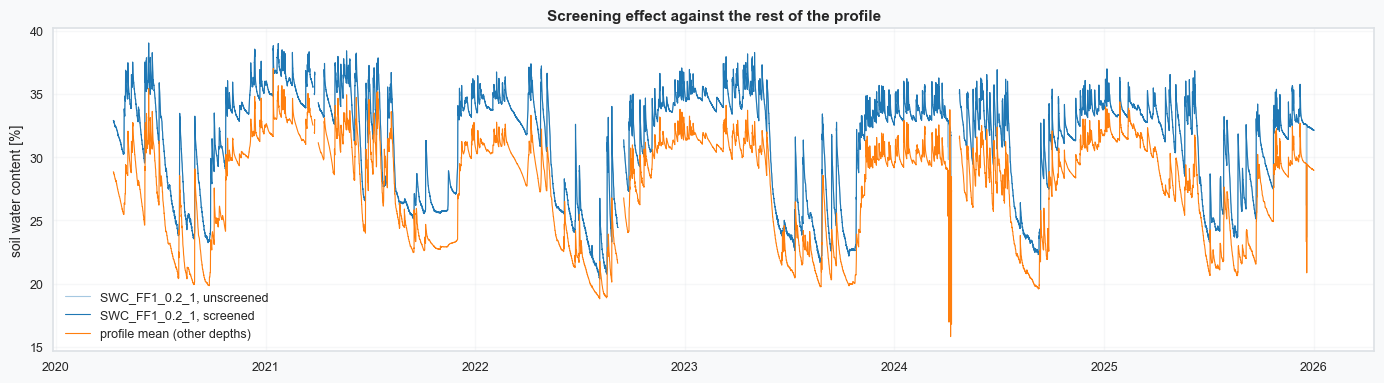

In [45]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(prof.index, prof[FIELD], label=f'{FIELD}, unscreened', color='tab:blue', alpha=.4, lw=.8)
ax.plot(_screened.index, _screened, label=f'{FIELD}, screened', color='tab:blue', lw=.8)
ax.plot(prof.index, prof[COMPANIONS].mean(axis=1), label='profile mean (other depths)',
        color='tab:orange', lw=.8)
ax.set_ylabel('soil water content [%]')
ax.set_title('Screening effect against the rest of the profile')
ax.legend()
plt.tight_layout()
plt.show()

### 🧪 Audit the screening in both directions
The re-check above is one number. This section asks the two questions that number cannot answer, and
prints the evidence for each:

1. **Is everything that was removed genuinely bad?** Nothing may leave the record without a committed
   test asking for it; every absolute-limits removal must really be outside `[SWC_MIN, SWC_MAX]`; and
   removing an isolated bad minute must not empty the 30MIN mean that contained it.
2. **Is everything real still there?** Every rain event > 10 mm/day inside the record must keep its
   response, and the agreement with the rest of the profile must not get worse.

At this depth `REMOVE_DATES` is empty, so the only value-removing test is absolute limits — which makes
the first question easy to answer and the second one the real check.

In [46]:
_ERA_SPLIT = pd.Timestamp('2021-03-27')  # 10MIN -> 1MIN, the March 2021 logger rebuild
_raw_hires = data_detailed[FIELD][FIELD].dropna()
_oor = _raw_hires[(_raw_hires < SWC_MIN) | (_raw_hires > SWC_MAX)]
_surv = mscr.series_hires_cleaned[FIELD].dropna()

print('AUDIT 1 - is everything that was removed genuinely bad?')
print(f'  manual-removal windows committed:         {len(REMOVE_DATES)}')
print(f'  out-of-range records in the raw series:   {len(_oor)}  '
      f'(10MIN era {int((_oor.index <= _ERA_SPLIT).sum())}, '
      f'1MIN era {int((_oor.index > _ERA_SPLIT).sum())})')
if len(_oor):
    print(f'  their value range:                        '
          f'{_oor.min():.2f} .. {_oor.max():.2f} % VWC')
    assert ((_oor < SWC_MIN) | (_oor > SWC_MAX)).all(), \
        '(!) a record counted as out-of-range is actually inside the physical range'
assert _surv.between(SWC_MIN, SWC_MAX).all(), '(!) an out-of-range value survived screening'
print(f'  surviving hi-res values, all in [{SWC_MIN}, {SWC_MAX}]:  '
      f'{_surv.min():.2f} .. {_surv.max():.2f} % VWC  -> PASSED')

# Removing an isolated bad minute must not empty the half hour that held it.
_bins_with_oor = pd.DatetimeIndex(_oor.index).ceil('30min').unique() if len(_oor) else pd.DatetimeIndex([])
_still = _screened.reindex(_bins_with_oor)
print(f'  30MIN periods containing a removed out-of-range minute: {len(_bins_with_oor)}')
print(f'     of these, still holding a screened value:            {int(_still.notna().sum())}')
print('     (any shortfall sits inside the April 2024 / Dec 2025 logger trouble, where the '
      'half hour was already short of records - not a consequence of the removal)')

print('\nAUDIT 2 - is everything real still there?')
_daily_after = _daily.copy()
_daily_after[FIELD] = _screened.resample('D').mean()

# The question is whether screening SHRANK a response, so the test is one-sided.
# Events falling inside a pre-existing gap are counted separately: the sensor was not
# measuring then, so there is no response for screening to preserve or destroy.
_ok, _gap, _damaged = 0, 0, []
for _day in resp.index:
    _rise_before = resp.loc[_day, FIELD]
    if pd.isna(_rise_before):
        _gap += 1
        continue
    _b = _daily_after.loc[:_day - pd.Timedelta('1D'), FIELD].dropna().tail(1)
    _a = _daily_after.loc[_day:_day + pd.Timedelta('2D'), FIELD].dropna()
    if _b.empty or _a.empty:
        _damaged.append(_day)
        continue
    if (_a.max() - _b.iloc[0]) >= _rise_before - 0.05:
        _ok += 1
    else:
        _damaged.append(_day)
print(f'  rain events > 10 mm/day in the record:        {len(resp)}')
print(f'     events inside a pre-existing gap (no response to keep): {_gap}')
print(f'     response fully preserved after screening:               {_ok}')
if _damaged:
    print(f'     (!) response LOST or shrunk: {[str(d.date()) for d in _damaged]}')
else:
    print('     no rain response was damaged by screening -> PASSED')

_rc_after = _daily_after[FIELD].diff().rolling(30, min_periods=20).corr(
    _daily_after[COMPANIONS].mean(axis=1).diff())
print(f'  days with rolling r < 0.3, before -> after:   '
      f'{int((rollcorr < 0.3).sum())} -> {int((_rc_after < 0.3).sum())}')
print(f'  median rolling r,          before -> after:   '
      f'{rollcorr.median():.3f} -> {_rc_after.median():.3f}')
if _rc_after.median() >= rollcorr.median() - 0.01:
    print('  agreement with the rest of the profile did not degrade -> PASSED')
else:
    print('  (!) WARNING - agreement with the profile got worse. A test removed real data.')


AUDIT 1 - is everything that was removed genuinely bad?
  manual-removal windows committed:         0
  out-of-range records in the raw series:   19  (10MIN era 0, 1MIN era 19)
  their value range:                        -69.56 .. -13.87 % VWC
  surviving hi-res values, all in [0, 60]:  20.33 .. 39.12 % VWC  -> PASSED
  30MIN periods containing a removed out-of-range minute: 15
     of these, still holding a screened value:            9
     (any shortfall sits inside the April 2024 / Dec 2025 logger trouble, where the half hour was already short of records - not a consequence of the removal)

AUDIT 2 - is everything real still there?
  rain events > 10 mm/day in the record:        198
     events inside a pre-existing gap (no response to keep): 6
     response fully preserved after screening:               192
     no rain response was damaged by screening -> PASSED
  days with rolling r < 0.3, before -> after:   2 -> 2
  median rolling r,          before -> after:   0.943 -> 0.943
  

## ⬆️ Upload data to database

**Re-uploading overwrites the same variant — safe to re-run.** With `delete_from_db_before_upload=True` (below), the upload first *deletes*, then writes. The delete is scoped to the exact match `_measurement` + `varname` + `data_version` (`meteoscreening_diive`) over the uploaded time range, so re-screening a period replaces only its previous screened result. It never touches the raw data (different `data_version`, and a different `_raw` bucket), other variables, or other data versions. The delete-first step (rather than a plain overwrite) matters because InfluxDB keys a point by its full tag set: if a tag changed between runs (e.g. `units`, `gain`, `offset`), a plain write would leave the old point as a **duplicate** — the delete removes it regardless of tags.

Only the target variable is uploaded. The companion depths were read from the shared raw-profile file for the cross-check only, never written back, and each has its own notebook.

In [47]:
print(f'Uploading to bucket {BUCKET_PROCESSED}')
for v in mscr.resampled_detailed.keys():
    dbc.upload_singlevar(
        to_bucket=BUCKET_PROCESSED,
        to_measurement=assigned_measurements[v],
        var_df=mscr.resampled_detailed[v],
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        delete_from_db_before_upload=True,
    )

Uploading to bucket ch-lae_processed


> Deleted variables ['SWC_FF1_0.2_1'] between 2020-04-10T15:00:00+01:00 and 
2026-01-01T00:00:00+01:00 from measurements ['SWC'] in bucket ch-lae_processed.

> Connecting to database ...

> --> UPLOAD TO DATABASE BUCKET ch-lae_processed:  ['SWC_FF1_0.2_1']

v Upload finished.

### Verify upload
Download the just-uploaded data back and confirm the time resolution and timestamps. The offset is the same `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the timestamps below should again be local `TIMESTAMP_END` — matching what you screened.

In [48]:
# Fresh variable names so the screened originals (data_detailed etc.) are not overwritten:
check_simple, check_detailed, check_measurements = dbc.download(
    bucket=BUCKET_PROCESSED,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version='meteoscreening_diive',
)
check_simple

> DOWNLOADING from bucket ch-lae_processed: variables ['SWC_FF1_0.2_1'] from measurements ['SWC'],
data version ['meteoscreening_diive'], between 2020-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone
offset to UTC 1)

> Downloaded data for 1 variables:

,SWC_FF1_0.2_1
TIMESTAMP_END,
2020-04-10 15:00:00,32.900000
2020-04-10 15:30:00,32.900000
2020-04-10 16:00:00,32.900000
2020-04-10 16:30:00,32.900000
2020-04-10 17:00:00,32.900000
...,...
2025-12-31 22:00:00,32.139789
2025-12-31 22:30:00,32.138521
2025-12-31 23:00:00,32.133453


In [49]:
for v in check_detailed.keys():
    idx = check_detailed[v].index
    freq = dv.times.DetectFrequency(index=idx, verbose=True).get()
    status = 'PASSED' if freq == RESAMPLING_FREQ else '(!) FAILED'
    print(f'{status} - {v}: freq={freq}, first={idx[0]}, last={idx[-1]}')

> Detect frequency: 30min (timedelta, 100% match)

PASSED - SWC_FF1_0.2_1: freq=30min, first=2020-04-10 15:00:00, last=2026-01-01 00:00:00


## ✅ End of notebook

In [50]:
_end = datetime.now()
print(f"Finished: {_end.strftime('%Y-%m-%d %H:%M:%S')}  "
      f"(runtime {str(_end - NOTEBOOK_START).split('.')[0]})")

Finished: 2026-07-22 12:49:27  (runtime 0:07:18)


***
### 📝 Notes for this variable
- **Mean, not sum.** `RESAMPLING_AGG = 'mean'` — soil water content is a state, not a flux.
- **Units are volumetric %,** stored with `gain = 100` on a raw `m^3/m^3` reading. The database unit tag says `%` for both eras of this record; the magnitudes (20-39) agree with that, and the export is checked against it above.
- **Sensor history.** The FF1 profile is five **TEROS 12** probes installed on 19 Mar 2020 (the old EC-20/M5 sensors were removed and trashed the same day) and first logged on 10 Apr 2020, which is where this record begins. The logger box was rebuilt on 24-26 Mar 2021, which changed the resolution from 10MIN to 1MIN but not the sensors. **This notebook screens the TEROS era only, by choice — the name is not empty before it.** `SWC_FF1_0.2_1` also carries 260,312 30MIN records under `data_version='meteoscreening_mst'`, 2004-09-07 to 2020-03-18, matching the fieldbook's 19 Mar 2020 removal entry, which notes that of the old probes only the 0.2 m one "was still running and measuring". That record is the old EC-20 (*M5*) profile **stored under the FF1 names** by the MeteoScreeningTool, and **this is the depth where that is provable**: over the 3,745 half-hours it shares with raw `SWC_M5_0.2_1` the two have the same mean (21.8320 vs 21.8320), a median ratio of 1.0000 and r = 0.998, with 21 % of the half-hours bit-identical. The raw `SWC_M5_*` names themselves exist only in `ch-lae_raw`, and only over 2020-01-01 → 2020-04-10. The two eras share no timestamp and the level steps by ≈ +10.7 % VWC here, so screening them together would be a splice of two instruments, not a continuation; they are joined in `30_PRODUCTS/09_METEO_SWC_FF1_2004-2025.ipynb` behind a `FLAG_..._SOURCE` flag, with a `_HOMOGENIZED` column beside the measured one.
- **Two raw time resolutions** (10MIN then 1MIN) — see the dedicated section above for what diive does with them and what it means for the tests. At 20 cm the split is 50,599 : 2,454,241 records.
- **The first 11 days are coarse.** From 2020-04-10 to 2020-04-21 values arrive in steps of 0.1% VWC (18 distinct values in 1,589 records); a logger software change on 21 Apr 2020 moved them to full float precision (333 distinct values in the next 336). The values are usable throughout, but do not read fine structure into that fortnight — and the one ≥ 24 h identical-value run in the whole record sits there.
- **A failed sensor read is a number, not a gap.** The CR1000 firmware predates SDI-12 NaN support, so a read that fails lands in the record as a fixed negative value (this sensor: −18.3 to −18.9 in April 2024, −69.6 in December 2025). That is why absolute limits, not the missing-values flag, is the test that catches them, and why a floor of `0` is not optional. Of the 19 in this record only 8 reach that test; the other 11 are discarded earlier, with the stray/isolated frequency groups of April 2024 and December 2025. None survives into the product.
- **The profile is the reference, and it is not a replicate set.** The depths differ in level and amplitude by design; only the *ordering* of the response is physically enforced (shallow wets first). Nothing from the companion depths is written into this series or uploaded. The 5 cm probe's Aug-Oct 2020 decoupled window is masked out of the companion mean here, because the companions are downloaded raw (unscreened).
- **Not a gap-filling source.** The companion depths and the precipitation product are used for comparison only.

***
### ✅ The verdict: a clean record, and the 2025 incident was the temperature sensor

The 20 cm sensor is the undramatic case in the FF1 profile. Across 2020-2025 it stays well-coupled to
the soil: the rolling 30-day agreement of daily increments with the rest of the profile holds at a
yearly-median r ≈ 0.92-0.96, dipping below 0.3 on exactly **two isolated days** (2022-08-02,
2023-08-25), both the flat-profile false positive where tiny changes are divided by tiny changes. The
rain-response ratio (this depth's rise after a > 10 mm day, over the profile mean's) is **healthy every
year** — median 0.98 / 0.90 / 1.07 / 1.29 / 1.10 / 1.24 for 2020-2025, sitting where a mid-profile
sensor should, between the sharper shallow probes and the damped 50 cm one. There is **no** analogue of
the 5 cm sensor's Aug-Oct 2020 decoupling: no rain event in five years passes 20 cm without moving it.

So `REMOVE_DATES` is empty and screening reduces to absolute limits plus the missing-values flag.

**Audited in both directions** (the *Audit the screening in both directions* cells above re-compute all
of this on every run):

- *Is everything removed genuinely bad?* With `REMOVE_DATES` empty, **absolute limits is the only
  value-removing test**, so nothing can leave the record without a physical rule asking for it. All 19
  out-of-range raw records are genuinely negative (−13.9 to −69.6% VWC, never a marginal case); 8 reach
  the test and 11 are discarded earlier with the stray/isolated frequency groups of April 2024 and
  December 2025. Each of the 8 is an isolated minute that leaves **6-29 in-range 1MIN records** in its
  30MIN bin, so **no half hour is emptied** by a removal, and nothing outside `[0, 60]` survives into
  the product.
- *Is everything real still there?* Of the **198 rain events > 10 mm/day** in the record, **192 keep
  their response intact** and the remaining **6 fall inside a pre-existing gap** (Sep 2022, April 2024),
  where the sensor was not measuring in the first place and there is no response for screening to
  preserve or destroy. **None is lost or shrunk** — there is no removal window for one to disappear
  into. The rolling 30-day agreement with the rest of the profile is likewise unchanged by screening:
  the same **two** single days below 0.3 before and after, median r **0.943 → 0.943**. That is what
  dropping a handful of isolated failed reads must look like; a drop there would have meant a test ate
  real soil moisture, and none did.

**The 27 Jun 2025 incident is the one thing to get right, and it is a red herring for this variable.**
The fieldbook logs, filed under this SWC device: *"TS_FF1_02_1 does not work regularly since 27.02"*
(27 Jun 2025), closed *"From the 06.07.2025 the sensor is working fine"*. The entry names
`TS_FF1_02_1` — the co-located soil **temperature** sensor — while sitting under the SWC operation
tag, so the data must decide which sensor it was. The soil-**water** record settles it: across
27 Feb → 6 Jul 2025 it is complete and healthy.

| Check over 27 Feb → 6 Jul 2025 | `SWC_FF1_0.2_1` |
|---|---|
| daily record count (target) | median 1,440; min 1,411 (2025-04-10), else 1,439-1,440 |
| out-of-range values | 0 |
| missing records | 0 |
| longest identical-value run | 2 minutes |
| monthly mean, Feb → Jul [% VWC] | 33.9 → 33.6 → 33.0 → 32.4 → 29.1 → 26.0 (normal seasonal dry-down, matches prior years) |
| rain response, 2025 (ratio) | 1.24 all events / 1.26 Jul-Oct — intact |

No coverage loss, no level step, no loss of rain response, no flat run, nothing out of range. **The SWC
probe at 20 cm was working throughout; the incident was the co-located temperature sensor,
`TS_FF1_02_1`, not this one.** Nothing is removed for it.

### 🔎 Fieldbook cross-check (GIN export `CH-LAE-laegeren-export_20260719.csv`)

The export is read in the *Adjudicate the candidates* cell above; this is the summary. Events that
explain something in the data, none of which needs a removal beyond what the tests already do:

| Data feature | Fieldbook entry |
|---|---|
| 0.1% value steps, 2020-04-10 → 2020-04-21, and the one ≥ 24 h identical-value run | 2020-04-21, "New datalogger software with two byte precision for the soil profile measurement (Teros 12 and 21)" — after it, full float precision |
| Failed reads stored as fixed negative numbers rather than gaps | 2020-04-10, the CR1000 firmware predates SDI-12 NaN support and was deliberately not updated ("thinking of the imminent system upgrade") |
| Gap 2021-03-24 → 2021-03-29 (in pieces), and the 10MIN → 1MIN change | FF1 logger box rebuilt, all components shut down 24 Mar, new CR1000 and program, data acquisition restarted 26 Mar |
| Gap 2022-09-06 → 2022-09-16 (10 d) | FF1 12 V DC-DC power supply failed; "the data is missing for 10 days ... due to power outage at the FF1", replaced 16 Sep |
| Gap 2023-06-15 (≈ 1 d) | "There is a problem with the power at ch-lae ... the ff1 is [affected]. No system at ff1 was running for 'one day'"; "FF1 is running again" 16 Jun |
| 2024-04-03 → 2024-04-23: degraded logging, stray 2/3/5/6-minute records, negative reads, then out | the 0.3 m probe was failing and "caused an interruption of the SDI12 communication of all sensors at the same port"; unplugged 23 Apr 2024, which is exactly when this record resumes |
| Negative reads on all five depths, 18-19 Dec 2025 | two remote logger-program uploads to the FF1 meteo logger on exactly those days ("Remotly uploaded new loggerprogram", then a windvane fix) |
| Incident 27 Jun → 6 Jul 2025, filed under this SWC device | names `TS_FF1_02_1`, the co-located soil **temperature** sensor; the SWC record is clean through the window (table above) — the incident was the temperature sensor, not this probe |

**Unexplained:** two gaps have no fieldbook entry within ±3 days — **2024-06-29 → 2024-07-01** (44 h) and
**2024-10-16** (8 h). The first is the *same* gap the precipitation notebook flagged as unexplained, so
it is a station-wide outage rather than anything to do with the soil profile.

Two further entries were checked and leave **no** trace in this series, worth recording so nobody
re-opens them:

- **The 4 Mar 2025 replacement of the 0.3 m probe** (dead since 23 Apr 2024, replaced 40 cm down the
  slope with a ≈ 3% VWC level shift) is a **companion** event. It matters for how the profile mean is
  read — the companion set changes membership over 2024-2025 — but not for the 20 cm sensor itself,
  whose record is continuous across it.
- **The 23 Oct 2025 wind storm** brought a beech down onto the FF1 station and wrecked the above-ground
  sensors (mast tilted, TA/RH shelter shattered, radiation sensors near-vertical). The buried profile
  logged 1440 records/day throughout and all five depths wet up together with the storm rain — no gap,
  no step, nothing to remove. It will matter for the FF1 *meteo* variables, not for this one.

### ♻️ Reusing this notebook for the other depths

This notebook is itself a copy of the `SWC_FF1_0.05_1` pattern. To screen another depth, copy the
pattern (or this file), change **`DEPTH`** in *User settings*, and re-derive everything depth-specific.
Everything else — field name, companion list, buckets, upload target — is derived from `DEPTH`. Then:

1. **Re-run the cross-check and rebuild `CANDIDATES` from that depth's own scan output.** The candidate
   list and `REMOVE_DATES` are per depth; do not carry either over. Mask the 5 cm probe's Aug-Oct 2020
   window out of the companion mean (done in the profile-build cell) so it does not distort the 2020
   diagnostics. If a depth has no documented or evidence-based fault, leave `REMOVE_DATES` empty — the
   two manual-removal cells are guarded and skip themselves, as they do here at 20 cm.
2. **Expect the rain-response test to weaken with depth.** A ratio near 0 is damning at 5 cm and
   unremarkable at 50 cm. Read the *ordering* of the depths, not the absolute ratio. At 20 cm the ratio
   is healthy (≈ 1.1), which is exactly what a mid-profile sensor should show.
3. **Two depths carry known faults, already in the fieldbook.** `0.3` failed in April 2024, was
   unplugged on 23 Apr 2024 and replaced on 4 Mar 2025 — the replacement went in 40 cm down the slope
   and its level differs from the old one's by about 3% VWC, so screen the two eras as a sensor change
   inside one field name. `0.2` (this notebook) had an incident logged 27 Jun 2025 that named the
   co-located temperature sensor, not the SWC probe — resolved from the data as clean (see the verdict
   above).
4. **Do not carry over the absolute limits blindly** either, though `[0, 60]` is physical and holds for
   every depth at this site. Check the value range printed by the cross-check first (this depth: 20.4 to
   39.0% in range).
5. **If you add any outlier test, report its flagged count per era, never as a total.** Every depth has
   the same 10MIN-then-1MIN structure, so every depth has the same trap. This notebook commits no spike
   test for that reason, and because after absolute limits there is nothing spiky left to remove but
   real wetting fronts.